# Multi-Lable Toxic Language Detection

Sunab Ranjitkar (22085829)  
CS7050NI – Artificial Intelligence


## 1. Setup


In [62]:
# !pip install -q pandas numpy matplotlib seaborn wordcloud scikit-learn nltk spacy torch transformers && python -m spacy download en_core_web_sm
import sys
IN_COLAB = 'google.colab' in sys.modules
print('Colab' if IN_COLAB else 'Local', sys.version.split()[0])


Running on Colab: 3.12.13


In [63]:
import os, re, time, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve, hamming_loss,
    confusion_matrix, precision_recall_fscore_support
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Core libraries imported.')

Core libraries imported.


In [64]:
from pathlib import Path
FIG_DIRS = [Path('report/figures'), Path('report 2/figures'), Path('report3/figures')]
for d in FIG_DIRS:
    d.mkdir(parents=True, exist_ok=True)

def savefig(name, dpi=200):
    for d in FIG_DIRS:
        plt.savefig(d / f'{name}.png', dpi=dpi, bbox_inches='tight')


In [65]:
# NLTK + spaCy initialisation (auto-download on first run)
import nltk
for pkg in ['stopwords', 'punkt', 'punkt_tab']:
    try:
        nltk.data.find(f'corpora/{pkg}' if pkg == 'stopwords' else f'tokenizers/{pkg}')
    except LookupError:
        nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords
STOPWORDS_EN = set(stopwords.words('english'))

import spacy
try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
except OSError:
    from spacy.cli import download as spacy_download
    spacy_download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print('NLTK stopwords loaded:', len(STOPWORDS_EN))
print('spaCy model loaded   :', nlp.meta['name'])

NLTK stopwords loaded: 198
spaCy model loaded   : core_web_sm


In [66]:
# Resolve dataset location for local Jupyter, Colab uploads, or Google Drive.
from pathlib import Path

def resolve_dataset_dir():
    candidates = [
        Path('dataset'),
        Path.cwd() / 'dataset',
        Path('/content/dataset'),
        Path('/content/toxic-language-detections/dataset'),
        Path('/content/drive/MyDrive/toxic-language-detections/dataset'),
        Path('/content/drive/MyDrive/dataset'),
    ]
    for candidate in candidates:
        if (candidate / 'train_preprocessed.csv').exists():
            return candidate
    for root in (Path.cwd(), Path('/content'), Path('/content/drive/MyDrive')):
        if root.exists():
            for match in root.rglob('train_preprocessed.csv'):
                return match.parent
    raise FileNotFoundError(
        'Could not find train_preprocessed.csv. Upload the dataset to the Colab runtime, '
        'or mount Google Drive and place it under a dataset/ folder.'
    )

DATA_DIR = resolve_dataset_dir()
print('Using dataset directory:', DATA_DIR)


Using dataset directory: dataset


## 2. Load Dataset


In [67]:
train_csv = DATA_DIR / 'train_preprocessed.csv'
test_csv  = DATA_DIR / 'test_preprocessed.csv'

train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)

print('Dataset directory:', DATA_DIR)
print('Train CSV:', train_csv)
print('Test  CSV:', test_csv)
print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
train_df.head()

Dataset directory: dataset
Train CSV: dataset/train_preprocessed.csv
Test  CSV: dataset/test_preprocessed.csv
Train shape: (159571, 10)
Test  shape: (153164, 10)


,comment_text,id,identity_hate,insult,obscene,set,severe_toxic,threat,toxic,toxicity
0,explanation why the edits made under my userna...,0000997932d777bf,0.0,0.0,0.0,train,0.0,0.0,0.0,0.0
1,d aww he matches this background colour i m s...,000103f0d9cfb60f,0.0,0.0,0.0,train,0.0,0.0,0.0,0.0
2,hey man i m really not trying to edit war it...,000113f07ec002fd,0.0,0.0,0.0,train,0.0,0.0,0.0,0.0
3,more i can t make any real suggestions on im...,0001b41b1c6bb37e,0.0,0.0,0.0,train,0.0,0.0,0.0,0.0
4,you sir are my hero any chance you remember...,0001d958c54c6e35,0.0,0.0,0.0,train,0.0,0.0,0.0,0.0


In [68]:
LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

train_df = train_df.dropna(subset=['comment_text'] + LABEL_COLS).reset_index(drop=True)
train_df[LABEL_COLS] = train_df[LABEL_COLS].astype(int)

train_df['n_labels']    = train_df[LABEL_COLS].sum(axis=1)
train_df['is_toxic']    = (train_df['n_labels'] > 0).astype(int)
train_df['comment_len'] = train_df['comment_text'].astype(str).apply(len)
train_df['word_count']  = train_df['comment_text'].astype(str).apply(lambda x: len(x.split()))

print(f'Total labelled comments: {len(train_df):,}')
print(f'Any-label toxic        : {train_df.is_toxic.sum():,} ({train_df.is_toxic.mean()*100:.2f}%)')
train_df.head()

Total labelled comments: 159,571
Any-label toxic        : 16,225 (10.17%)


,comment_text,id,identity_hate,insult,obscene,set,severe_toxic,threat,toxic,toxicity,n_labels,is_toxic,comment_len,word_count
0,explanation why the edits made under my userna...,0000997932d777bf,0,0,0,train,0,0,0,0.0,0,0,252,46
1,d aww he matches this background colour i m s...,000103f0d9cfb60f,0,0,0,train,0,0,0,0.0,0,0,92,16
2,hey man i m really not trying to edit war it...,000113f07ec002fd,0,0,0,train,0,0,0,0.0,0,0,233,44
3,more i can t make any real suggestions on im...,0001b41b1c6bb37e,0,0,0,train,0,0,0,0.0,0,0,611,117
4,you sir are my hero any chance you remember...,0001d958c54c6e35,0,0,0,train,0,0,0,0.0,0,0,67,14


## 3. Exploratory Data Analysis

### 3.1 Label distribution


               count  pct_of_dataset
toxic          15294            9.58
obscene         8449            5.29
insult          7877            4.94
severe_toxic    1595            1.00
identity_hate   1405            0.88
threat           478            0.30


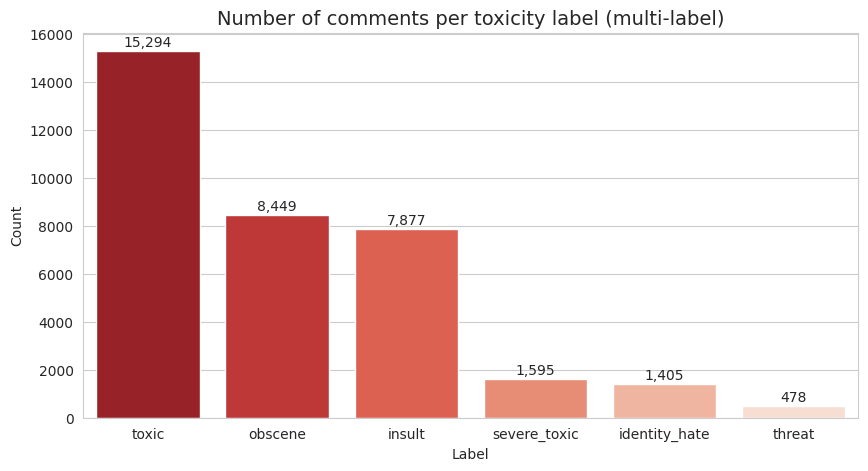

In [69]:
label_counts = train_df[LABEL_COLS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(train_df) * 100).round(2)
print(pd.DataFrame({'count': label_counts, 'pct_of_dataset': label_pct}))

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')
plt.title('Number of comments per toxicity label (multi-label)', fontsize=14)
plt.ylabel('Count'); plt.xlabel('Label')
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.show()

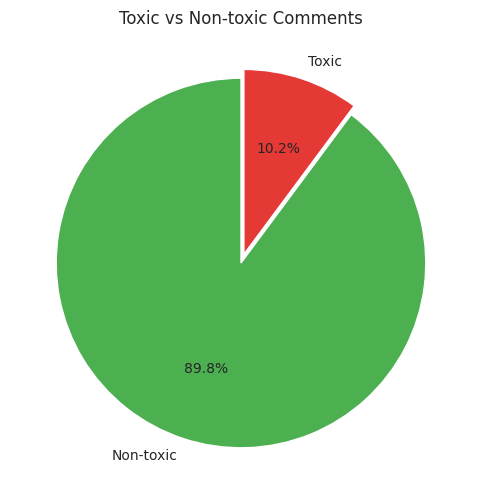

In [70]:
balance = train_df['is_toxic'].value_counts().rename({0: 'Non-toxic', 1: 'Toxic'})
plt.figure(figsize=(6, 6))
plt.pie(balance, labels=balance.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#E53935'], startangle=90, explode=[0, 0.05])
plt.title('Toxic vs Non-toxic Comments')
plt.show()

### 3.2 Labels per comment & co-occurrence


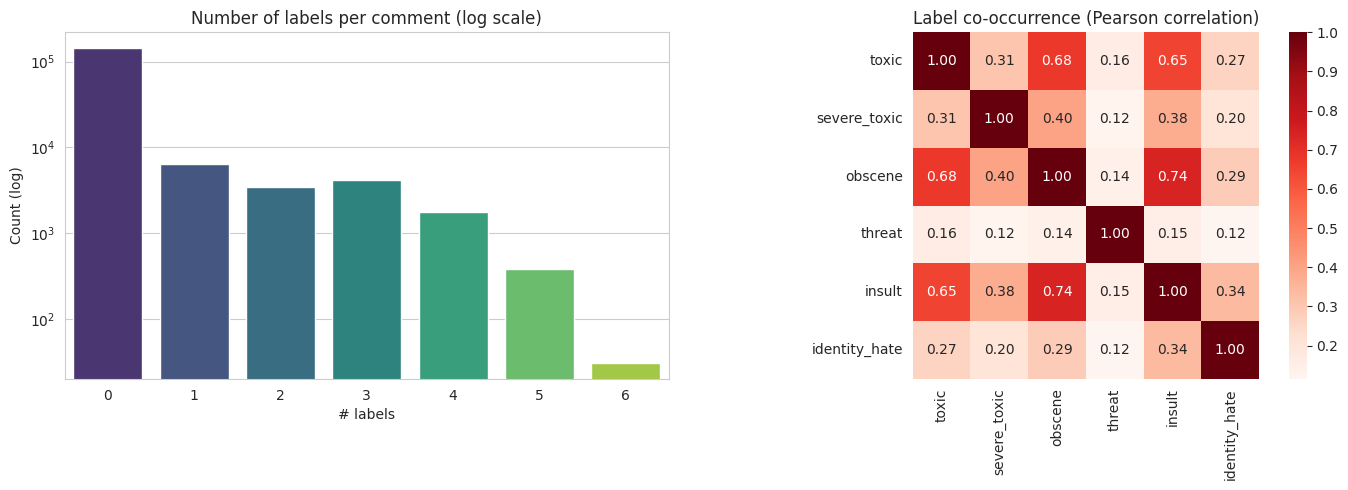

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='n_labels', data=train_df, palette='viridis', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Number of labels per comment (log scale)')
axes[0].set_xlabel('# labels'); axes[0].set_ylabel('Count (log)')

sns.heatmap(train_df[LABEL_COLS].corr(), annot=True, cmap='Reds',
            fmt='.2f', square=True, ax=axes[1])
axes[1].set_title('Label co-occurrence (Pearson correlation)')
plt.tight_layout(); plt.show()

### 3.3 Comment length


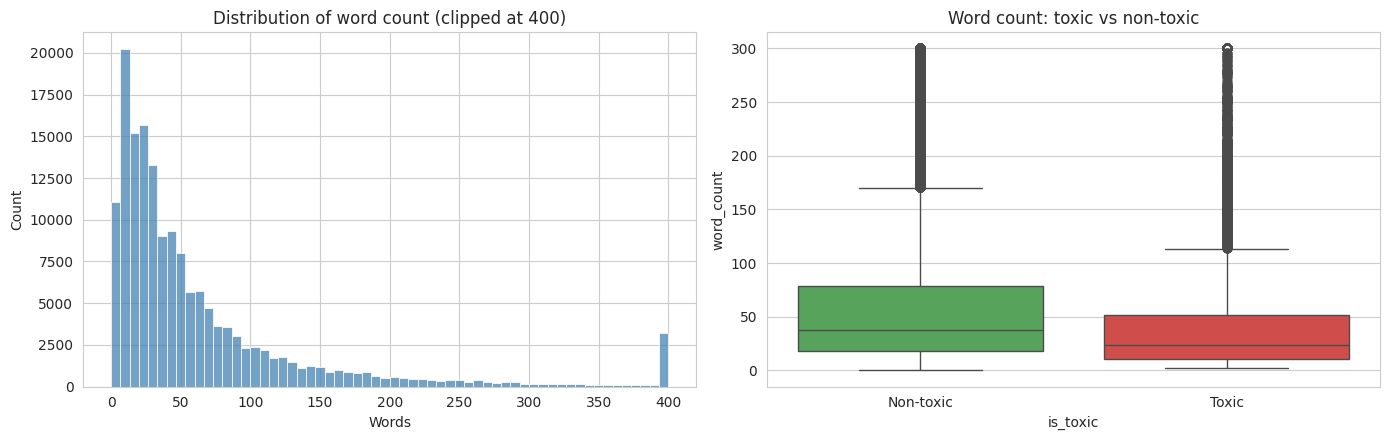

       comment_len  word_count
count     159571.0    159571.0
mean         380.0        68.4
std          571.6       101.6
min            1.0         0.0
25%           90.0        17.0
50%          197.0        36.0
75%          421.0        76.0
max         6251.0      1558.0


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(train_df['word_count'].clip(upper=400), bins=60,
             ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of word count (clipped at 400)')
axes[0].set_xlabel('Words')

sns.boxplot(x='is_toxic', y='word_count',
            data=train_df.assign(word_count=train_df['word_count'].clip(upper=300)),
            palette=['#4CAF50', '#E53935'], ax=axes[1])
axes[1].set_xticklabels(['Non-toxic', 'Toxic'])
axes[1].set_title('Word count: toxic vs non-toxic')
plt.tight_layout(); plt.show()

print(train_df[['comment_len', 'word_count']].describe().round(1))

### 3.4 Word clouds


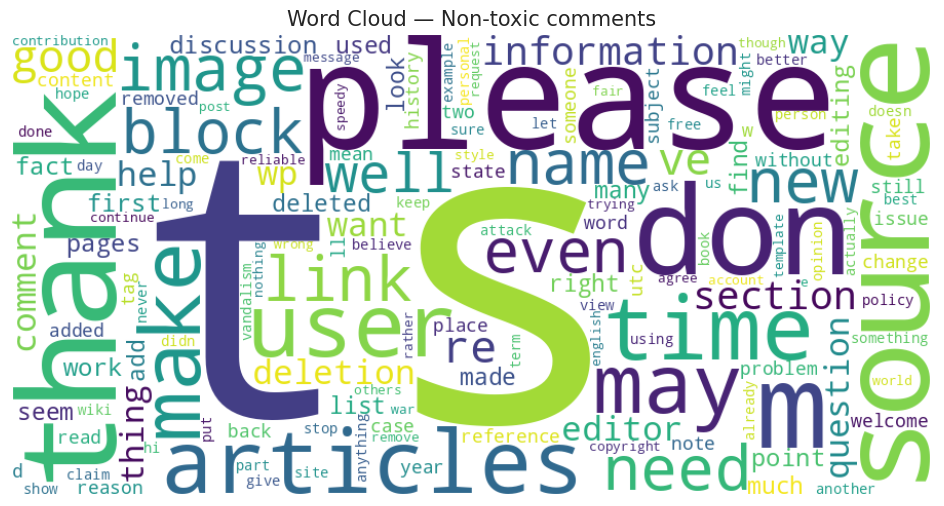

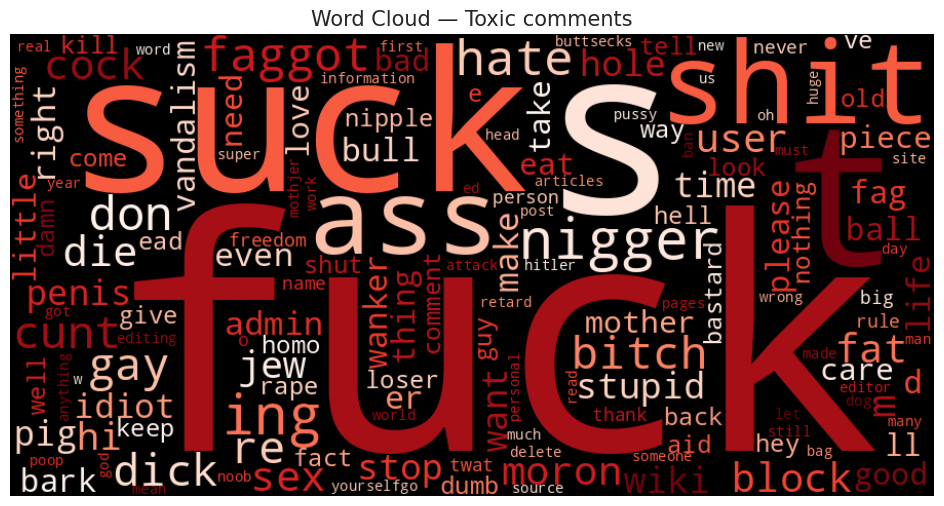

In [73]:
WC_STOP = set(STOPWORDS) | {'article', 'page', 'wikipedia', 'talk', 'edit', 'edits',
                            'one', 'will', 'now', 'use', 'know', 'people', 'think',
                            'see', 'really', 'said', 'say', 'go', 'going', 'u', 'im',
                            'thats', 'dont'}

def make_wordcloud(text, title, bg='white', cmap=None):
    wc = WordCloud(width=900, height=450, background_color=bg,
                   stopwords=WC_STOP, max_words=150, collocations=False,
                   colormap=cmap).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15)
    plt.show()

non_toxic_text = ' '.join(train_df.loc[train_df.is_toxic == 0, 'comment_text']
                                  .sample(n=20000, random_state=1))
toxic_text     = ' '.join(train_df.loc[train_df.is_toxic == 1, 'comment_text'])

make_wordcloud(non_toxic_text, 'Word Cloud — Non-toxic comments', 'white')
make_wordcloud(toxic_text,     'Word Cloud — Toxic comments',     'black', cmap='Reds')

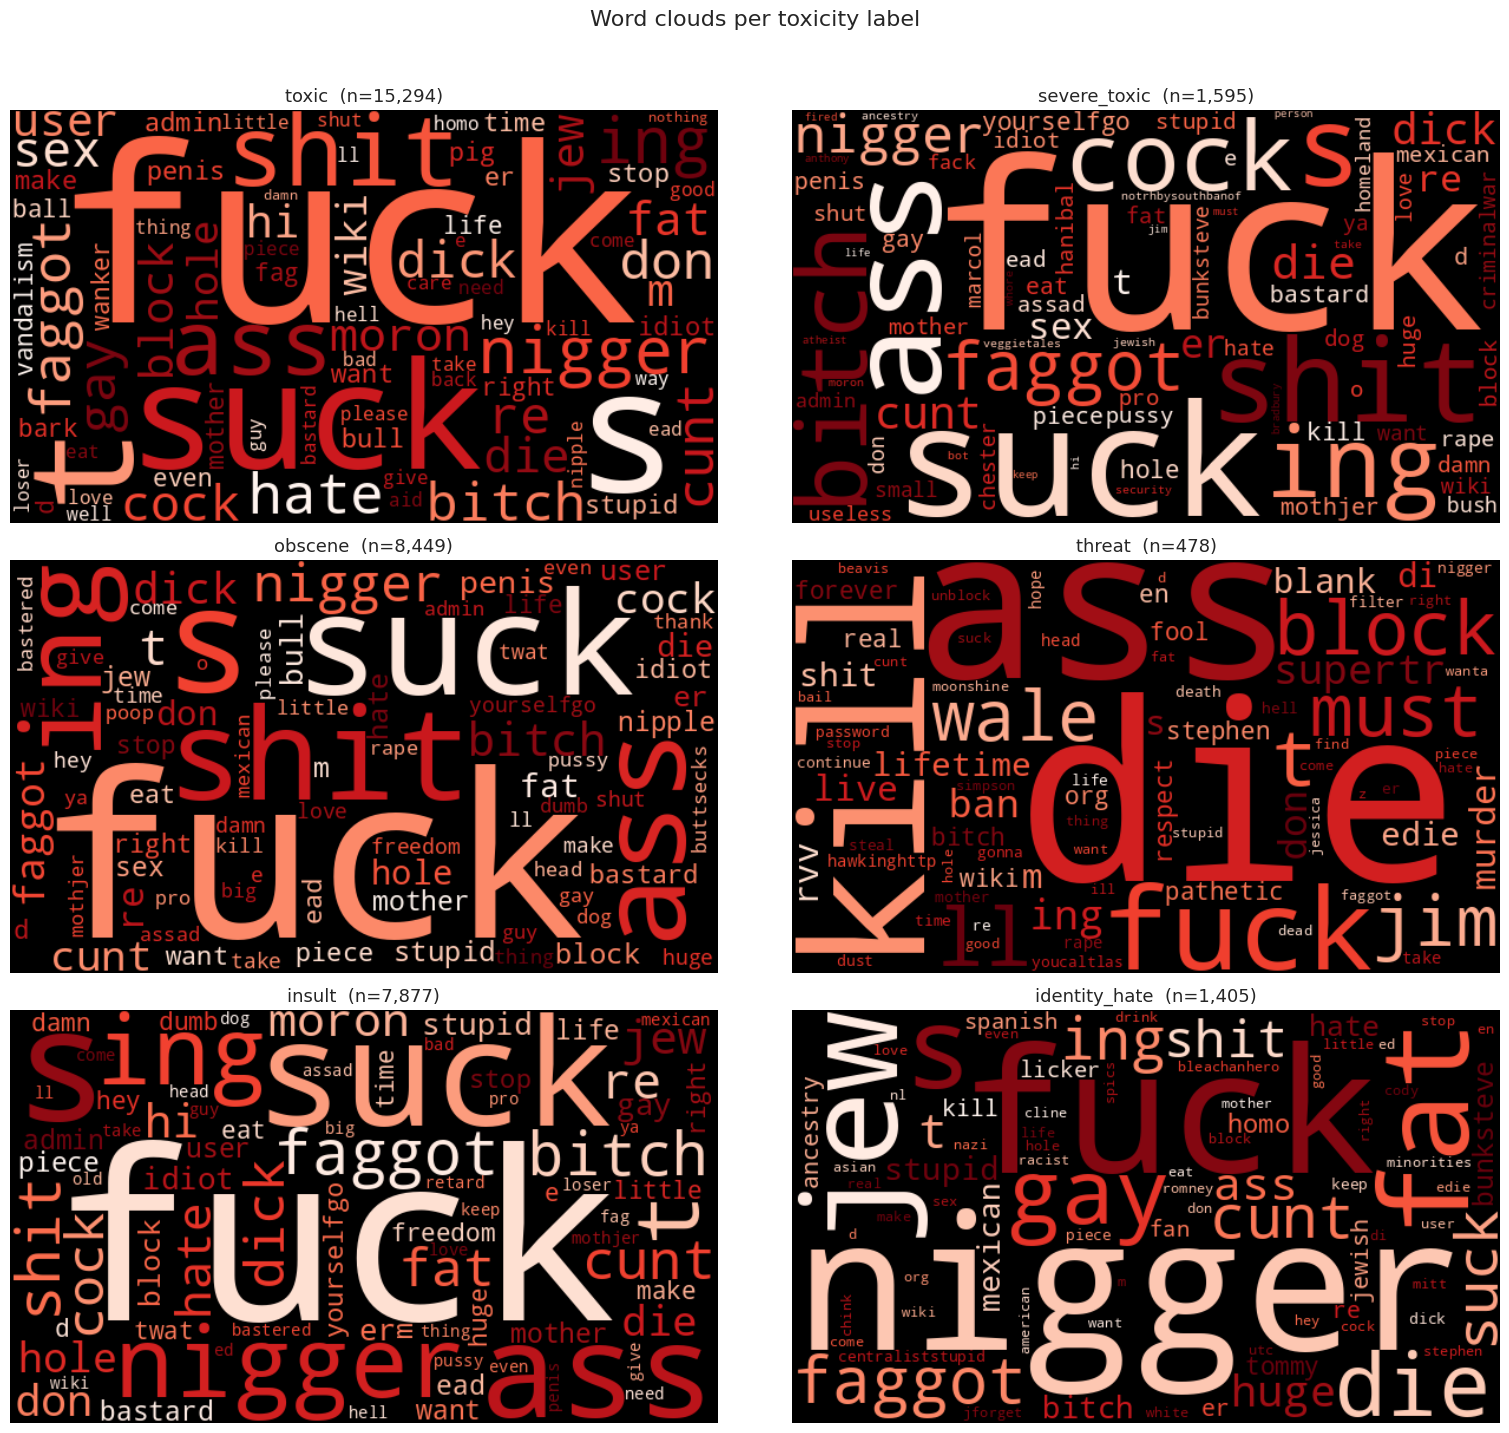

In [74]:
# Per-label word clouds
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for ax, label in zip(axes.flat, LABEL_COLS):
    text = ' '.join(train_df.loc[train_df[label] == 1, 'comment_text'])
    if not text.strip():
        ax.axis('off'); continue
    wc = WordCloud(width=600, height=350, background_color='black',
                   stopwords=WC_STOP, max_words=80, collocations=False,
                   colormap='Reds').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label}  (n={int(train_df[label].sum()):,})', fontsize=13)
    ax.axis('off')
plt.suptitle('Word clouds per toxicity label', fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

### 3.5 Top n-grams in toxic comments


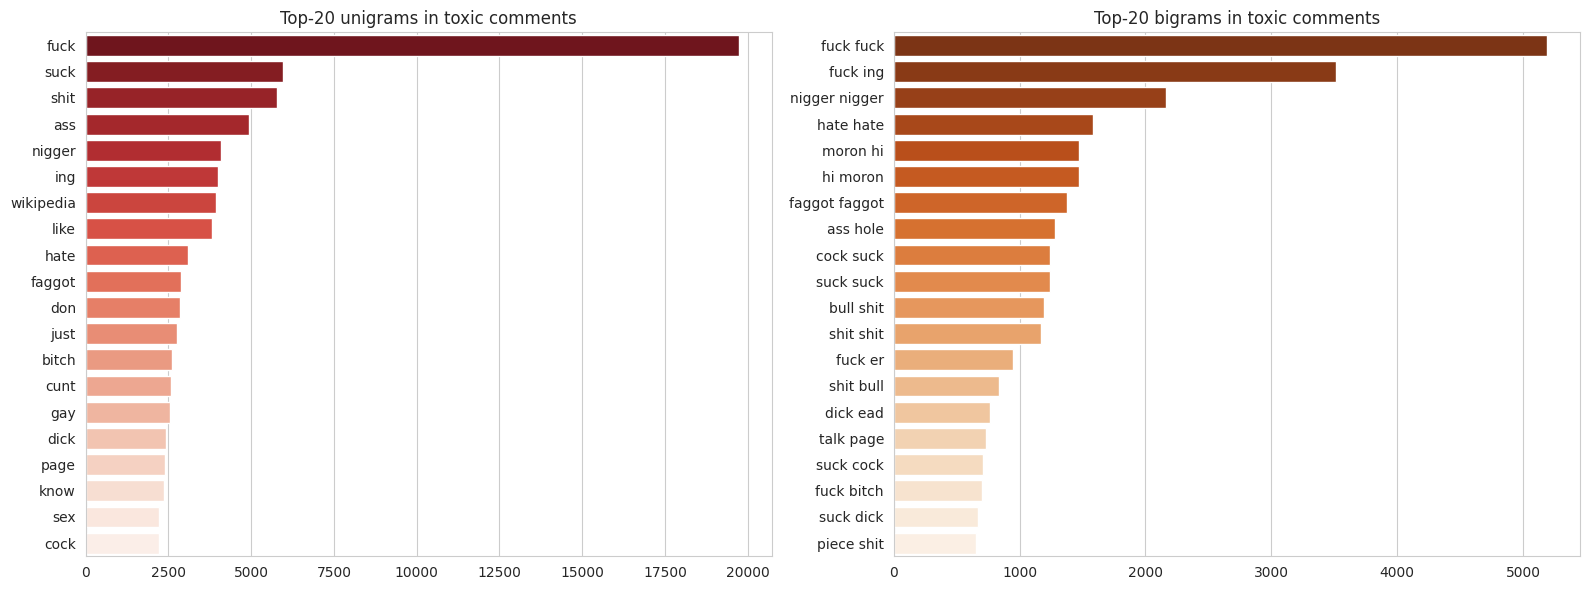

In [75]:
def top_ngrams(corpus, ngram_range=(1, 1), n=20):
    cv = CountVectorizer(ngram_range=ngram_range, stop_words='english', min_df=5)
    X = cv.fit_transform(corpus)
    sums = np.asarray(X.sum(axis=0)).ravel()
    return sorted(zip(cv.get_feature_names_out(), sums),
                  key=lambda x: x[1], reverse=True)[:n]

toxic_corpus = train_df.loc[train_df.is_toxic == 1, 'comment_text'].astype(str)
top_uni  = top_ngrams(toxic_corpus, (1, 1), 20)
top_bi   = top_ngrams(toxic_corpus, (2, 2), 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(y=[w for w, _ in top_uni], x=[c for _, c in top_uni],
            ax=axes[0], palette='Reds_r')
axes[0].set_title('Top-20 unigrams in toxic comments')
sns.barplot(y=[w for w, _ in top_bi], x=[c for _, c in top_bi],
            ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top-20 bigrams in toxic comments')
plt.tight_layout(); plt.show()

## 4. Classical Pipeline Pre-processing


In [ ]:
URL_RE   = re.compile(r'http\S+|www\.\S+')
HTML_RE  = re.compile(r'<[^>]+>')
PUNCT_RE = re.compile(f'[{re.escape(string.punctuation)}]')
NUM_RE   = re.compile(r'\d+')
WS_RE    = re.compile(r'\s+')

def basic_clean(text: str) -> str:
    text = str(text).lower()
    text = HTML_RE.sub(' ', text)
    text = URL_RE.sub(' ', text)
    text = PUNCT_RE.sub(' ', text)
    text = NUM_RE.sub(' ', text)
    return WS_RE.sub(' ', text).strip()

def remove_stopwords(text: str) -> str:
    return ' '.join(t for t in text.split() if t not in STOPWORDS_EN and len(t) > 1)

def lemmatise_batch(texts, batch_size=1000, n_process=1):
    """spaCy lemmatisation in batches (much faster than per-doc loop)."""
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        out.append(' '.join(tok.lemma_ for tok in doc if not tok.is_space))
    return out

print('Cleaning text…')
t0 = time.time()
train_df['cleaned']    = train_df['comment_text'].apply(basic_clean)
train_df['no_stop']    = train_df['cleaned'].apply(remove_stopwords)
print(f'  basic clean + stop-words: {time.time()-t0:.1f}s')

print('Lemmatising with spaCy (this can take a few minutes)…')
t0 = time.time()
train_df['lemmatised'] = lemmatise_batch(train_df['no_stop'].tolist(),
                                         batch_size=2000, n_process=1)
print(f'  lemmatisation: {time.time()-t0:.1f}s')

train_df[['comment_text', 'cleaned', 'no_stop', 'lemmatised']].head(3)

Cleaning text…
  basic clean + stop-words: 9.1s
Lemmatising with spaCy (this can take a few minutes)…


### 4.1 Train / Validation split (80/20, stratified)


In [ ]:
X_text = train_df['lemmatised'].values
X_raw  = train_df['comment_text'].values   # for the transformer
y      = train_df[LABEL_COLS].values.astype(np.float32)

idx_train, idx_val = train_test_split(
    np.arange(len(train_df)),
    test_size=0.20, random_state=RANDOM_STATE,
    stratify=train_df['is_toxic']
)

X_train_text, X_val_text = X_text[idx_train], X_text[idx_val]
X_train_raw,  X_val_raw  = X_raw[idx_train],  X_raw[idx_val]
y_train,      y_val      = y[idx_train],      y[idx_val]

print(f'Train size: {len(X_train_text):,}')
print(f'Val   size: {len(X_val_text):,}')
print('Class distribution in train (per label):')
print(pd.DataFrame(y_train, columns=LABEL_COLS).sum().astype(int))

Train size: 127,656
Val   size: 31,915
Class distribution in train (per label):
toxic            12248
severe_toxic      1290
obscene           6787
threat             380
insult            6301
identity_hate     1146
dtype: int64


## 5. Model 1 — TF-IDF + Logistic Regression


In [ ]:
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    ngram_range=(1, 2),
    max_features=50000,
    min_df=3
)

t0 = time.time()
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)
tfidf_fit_time = time.time() - t0
print(f'TF-IDF matrix: {X_train_tfidf.shape}  (fit in {tfidf_fit_time:.1f}s)')

TF-IDF matrix: (127656, 50000)  (fit in 17.5s)


In [ ]:
lr = OneVsRestClassifier(
    LogisticRegression(C=4.0, solver='liblinear',
                       class_weight='balanced', max_iter=1000)
)

t0 = time.time()
lr.fit(X_train_tfidf, y_train)
lr_train_time = time.time() - t0

t0 = time.time()
y_pred_lr  = lr.predict(X_val_tfidf)
y_proba_lr = lr.predict_proba(X_val_tfidf)
lr_pred_time = time.time() - t0

print(f'Logistic Regression  train time: {lr_train_time:.1f}s')
print(f'Logistic Regression  pred  time: {lr_pred_time:.2f}s')

Logistic Regression  train time: 17.0s
Logistic Regression  pred  time: 0.05s


In [ ]:
print('=== Logistic Regression — validation results ===')
print(f"Subset accuracy : {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"Hamming loss    : {hamming_loss(y_val, y_pred_lr):.4f}")
print(f"Macro F1        : {f1_score(y_val, y_pred_lr, average='macro'):.4f}")
print(f"Micro F1        : {f1_score(y_val, y_pred_lr, average='micro'):.4f}")
print(f"Macro ROC-AUC   : {roc_auc_score(y_val, y_proba_lr, average='macro'):.4f}")
print('\nPer-label classification report:')
print(classification_report(y_val, y_pred_lr, target_names=LABEL_COLS, zero_division=0))

=== Logistic Regression — validation results ===
Subset accuracy : 0.8916
Hamming loss    : 0.0252
Macro F1        : 0.5920
Micro F1        : 0.7099
Macro ROC-AUC   : 0.9796

Per-label classification report:
               precision    recall  f1-score   support

        toxic       0.69      0.85      0.76      3046
 severe_toxic       0.30      0.81      0.43       305
      obscene       0.73      0.88      0.80      1662
       threat       0.32      0.72      0.44        98
       insult       0.60      0.86      0.71      1576
identity_hate       0.28      0.72      0.41       259

    micro avg       0.61      0.85      0.71      6946
    macro avg       0.49      0.81      0.59      6946
 weighted avg       0.64      0.85      0.73      6946
  samples avg       0.06      0.08      0.07      6946



## 6. DistilBERT Tokeniser


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)

DEVICE = torch.device('cuda' if torch.cuda.is_available()
                       else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Torch:', torch.__version__, '  Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# ---- Hyper-parameters (tweak as needed) ----
MODEL_NAME   = 'distilbert-base-uncased'
MAX_LEN      = 128
BATCH_SIZE   = 64 if DEVICE.type == 'cuda' else 16
EPOCHS       = 2
LR           = 2e-5
WEIGHT_DECAY = 0.01
USE_AMP      = (DEVICE.type == 'cuda')   # mixed-precision training on GPU
SUBSAMPLE    = None   # e.g. 30000 for quick experimentation; None = use full set


Torch: 2.10.0+cu128   Device: cuda
GPU   : Tesla T4


In [ ]:
if SUBSAMPLE is not None:
    rng = np.random.RandomState(RANDOM_STATE)
    keep_train = rng.choice(len(X_train_raw),
                            size=min(SUBSAMPLE, len(X_train_raw)),
                            replace=False)
    keep_val   = rng.choice(len(X_val_raw),
                            size=min(SUBSAMPLE // 5, len(X_val_raw)),
                            replace=False)
    Xtr_raw, ytr = X_train_raw[keep_train], y_train[keep_train]
    Xvl_raw, yvl = X_val_raw[keep_val],     y_val[keep_val]
else:
    Xtr_raw, ytr = X_train_raw, y_train
    Xvl_raw, yvl = X_val_raw,   y_val

print(f'Transformer train size: {len(Xtr_raw):,}')
print(f'Transformer val   size: {len(Xvl_raw):,}')

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = labels.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float32),
        }

train_ds = ToxicDataset(Xtr_raw, ytr, tokenizer, MAX_LEN)
val_ds   = ToxicDataset(Xvl_raw, yvl, tokenizer, MAX_LEN)
_pin = (DEVICE.type == 'cuda')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=_pin)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0, pin_memory=_pin)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Transformer train size: 127,656
Transformer val   size: 31,915


Transformer train size: 127,656
Transformer val   size: 31,915


Transformer train size: 127,656
Transformer val   size: 31,915


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Transformer train size: 127,656
Transformer val   size: 31,915


...

Transformer train size: 127,656
Transformer val   size: 31,915


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 1995  Val batches: 250


## 7. Model 2 — Fine-tuned DistilBERT


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLS),
    problem_type='multi_label_classification'
).to(DEVICE)

no_decay = ['bias', 'LayerNorm.weight']
grouped = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = AdamW(grouped, lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f'Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 67.0M


In [ ]:
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

def run_epoch(model, loader, optimizer=None, scheduler=None, epoch_tag=''):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, n = 0.0, 0
    all_logits, all_labels = [], []
    start_t = time.time()
    PRINT_EVERY = max(1, len(loader) // 20)   # ~20 progress lines per epoch
    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        labels         = batch['labels'].to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = out.loss
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            if USE_AMP:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            if scheduler is not None: scheduler.step()
        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
        all_logits.append(out.logits.detach().float().cpu())
        all_labels.append(labels.detach().cpu())
        if step % PRINT_EVERY == 0 or step == len(loader) - 1:
            elapsed = time.time() - start_t
            running = total_loss / max(n, 1)
            phase   = 'train' if is_train else 'val  '
            print(f'  [{epoch_tag} {phase}] step {step+1:>5d}/{len(loader)}  '
                  f'loss={loss.item():.4f}  running={running:.4f}  '
                  f'elapsed={elapsed:6.1f}s')
    return (total_loss / n,
            torch.cat(all_logits).numpy(),
            torch.cat(all_labels).numpy())

history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_auc': [],
           'epoch_time_s': []}
overall_t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    print(f'\n========== Epoch {epoch}/{EPOCHS} ==========')
    ep_t0 = time.time()
    tr_loss, _, _ = run_epoch(model, train_loader, optimizer, scheduler,
                              epoch_tag=f'E{epoch}')
    vl_loss, vl_logits, vl_labels = run_epoch(model, val_loader,
                                              epoch_tag=f'E{epoch}')
    vl_proba = 1 / (1 + np.exp(-vl_logits))
    vl_auc   = roc_auc_score(vl_labels, vl_proba, average='macro')
    ep_time  = time.time() - ep_t0
    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_auc'].append(vl_auc)
    history['epoch_time_s'].append(ep_time)
    print(f'  >>> Epoch {epoch} summary: '
          f'train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  '
          f'val_macroAUC={vl_auc:.4f}  time={ep_time/60:.1f} min')

bert_train_time = time.time() - overall_t0
print(f'\nDistilBERT total training time: {bert_train_time/60:.1f} min')
print('\nPer-epoch history:')
print(pd.DataFrame(history).to_string(index=False))



========== Epoch 1/2 ==========
  [E1 train] step     1/1995  loss=0.7291  running=0.7291  elapsed=   1.4s
  [E1 train] step   100/1995  loss=0.3826  running=0.6195  elapsed=  20.2s
  [E1 train] step   199/1995  loss=0.1857  running=0.4414  elapsed=  39.6s
  [E1 train] step   298/1995  loss=0.0834  running=0.3354  elapsed=  58.9s
  [E1 train] step   397/1995  loss=0.0509  running=0.2703  elapsed=  78.6s
  [E1 train] step   496/1995  loss=0.0402  running=0.2273  elapsed=  98.8s
  [E1 train] step   595/1995  loss=0.0174  running=0.1983  elapsed= 118.9s
  [E1 train] step   694/1995  loss=0.0357  running=0.1777  elapsed= 139.4s
  [E1 train] step   793/1995  loss=0.0594  running=0.1615  elapsed= 159.8s
  [E1 train] step   892/1995  loss=0.0696  running=0.1489  elapsed= 180.6s
  [E1 train] step   991/1995  loss=0.0792  running=0.1387  elapsed= 201.6s
  [E1 train] step  1090/1995  loss=0.0346  running=0.1301  elapsed= 222.6s
  [E1 train] step  1189/1995  loss=0.0486  running=0.1231  elapsed=

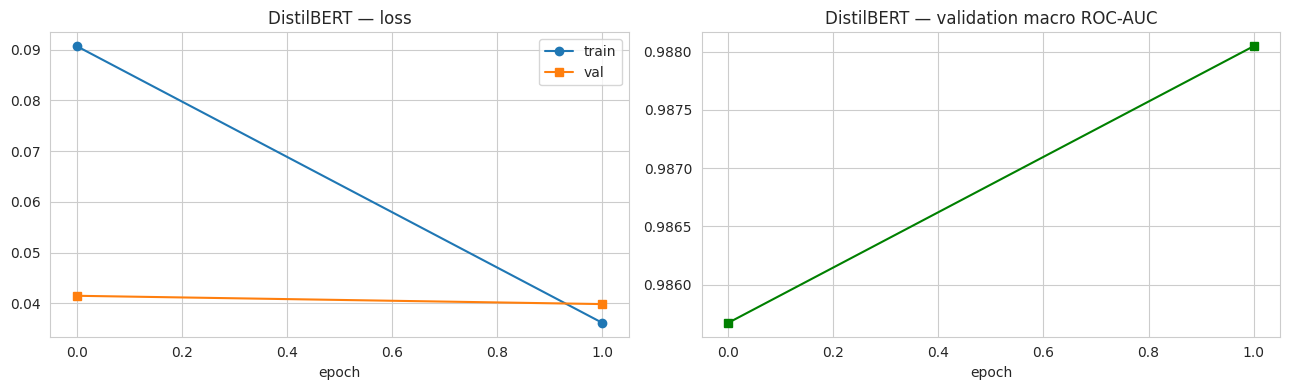

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_loss'], 'o-', label='train')
axes[0].plot(history['val_loss'],   's-', label='val')
axes[0].set_title('DistilBERT — loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history['val_auc'], 's-', color='green')
axes[1].set_title('DistilBERT — validation macro ROC-AUC')
axes[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

In [ ]:
# Final inference on validation set (with timing)
t0 = time.time()
_, val_logits, val_labels = run_epoch(model, val_loader)
bert_pred_time = time.time() - t0
y_proba_bert = 1 / (1 + np.exp(-val_logits))
y_pred_bert  = (y_proba_bert >= 0.5).astype(int)
y_val_bert   = val_labels.astype(int)

print(f'DistilBERT inference time: {bert_pred_time:.1f}s for {len(y_val_bert):,} samples')
print('\n=== DistilBERT — validation results ===')
print(f"Subset accuracy : {accuracy_score(y_val_bert, y_pred_bert):.4f}")
print(f"Hamming loss    : {hamming_loss(y_val_bert, y_pred_bert):.4f}")
print(f"Macro F1        : {f1_score(y_val_bert, y_pred_bert, average='macro'):.4f}")
print(f"Micro F1        : {f1_score(y_val_bert, y_pred_bert, average='micro'):.4f}")
print(f"Macro ROC-AUC   : {roc_auc_score(y_val_bert, y_proba_bert, average='macro'):.4f}")
print('\nPer-label classification report:')
print(classification_report(y_val_bert, y_pred_bert, target_names=LABEL_COLS, zero_division=0))

  [ val  ] step     1/250  loss=0.0535  running=0.0535  elapsed=   0.2s
  [ val  ] step    13/250  loss=0.0449  running=0.0413  elapsed=   2.5s
  [ val  ] step    25/250  loss=0.0270  running=0.0365  elapsed=   4.5s
  [ val  ] step    37/250  loss=0.0394  running=0.0391  elapsed=   6.4s
  [ val  ] step    49/250  loss=0.0482  running=0.0383  elapsed=   8.3s
  [ val  ] step    61/250  loss=0.0488  running=0.0391  elapsed=  10.2s
  [ val  ] step    73/250  loss=0.0348  running=0.0398  elapsed=  12.1s
  [ val  ] step    85/250  loss=0.0706  running=0.0413  elapsed=  14.3s
  [ val  ] step    97/250  loss=0.0612  running=0.0408  elapsed=  16.6s
  [ val  ] step   109/250  loss=0.0206  running=0.0406  elapsed=  18.5s
  [ val  ] step   121/250  loss=0.0376  running=0.0409  elapsed=  20.4s
  [ val  ] step   133/250  loss=0.0369  running=0.0408  elapsed=  22.3s
  [ val  ] step   145/250  loss=0.0355  running=0.0407  elapsed=  24.2s
  [ val  ] step   157/250  loss=0.0382  running=0.0410  elapsed=

## 8. Per-label Threshold Tuning


In [ ]:
def tune_thresholds(y_true, y_proba, grid=np.linspace(0.05, 0.95, 19)):
    best = []
    for j in range(y_true.shape[1]):
        f1s = [f1_score(y_true[:, j], (y_proba[:, j] >= t).astype(int),
                        zero_division=0) for t in grid]
        best.append(grid[int(np.argmax(f1s))])
    return np.array(best)

thr_lr   = tune_thresholds(y_val,      y_proba_lr)
thr_bert = tune_thresholds(y_val_bert, y_proba_bert)

thr_df = pd.DataFrame({'logreg': thr_lr, 'distilbert': thr_bert}, index=LABEL_COLS)
print('Per-label optimal thresholds:')
print(thr_df.round(3))

y_pred_lr_t   = (y_proba_lr   >= thr_lr).astype(int)
y_pred_bert_t = (y_proba_bert >= thr_bert).astype(int)

print(f"\nLogistic Regression — Macro F1 (default 0.5): "
      f"{f1_score(y_val, y_pred_lr,  average='macro'):.4f}")
print(f"Logistic Regression — Macro F1 (tuned thr) : "
      f"{f1_score(y_val, y_pred_lr_t, average='macro'):.4f}")
print(f"DistilBERT          — Macro F1 (default 0.5): "
      f"{f1_score(y_val_bert, y_pred_bert,  average='macro'):.4f}")
print(f"DistilBERT          — Macro F1 (tuned thr) : "
      f"{f1_score(y_val_bert, y_pred_bert_t, average='macro'):.4f}")

Per-label optimal thresholds:
               logreg  distilbert
toxic            0.75        0.55
severe_toxic     0.85        0.30
obscene          0.75        0.50
threat           0.70        0.25
insult           0.80        0.50
identity_hate    0.85        0.35

Logistic Regression — Macro F1 (default 0.5): 0.5920
Logistic Regression — Macro F1 (tuned thr) : 0.6352
DistilBERT          — Macro F1 (default 0.5): 0.6320
DistilBERT          — Macro F1 (tuned thr) : 0.6806


## 9. Evaluation

### 9.1 Summary table


In [ ]:
def metrics_row(name, y_true, y_pred, y_score, train_t=None, pred_t=None):
    return {
        'Model'         : name,
        'Accuracy'      : accuracy_score(y_true, y_pred),
        'Hamming Loss'  : hamming_loss(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall'  : recall_score(y_true,   y_pred, average='macro', zero_division=0),
        'Macro F1'      : f1_score(y_true,       y_pred, average='macro', zero_division=0),
        'Micro F1'      : f1_score(y_true,       y_pred, average='micro', zero_division=0),
        'Macro ROC-AUC' : roc_auc_score(y_true,  y_score, average='macro'),
        'Train (s)'     : round(train_t, 1) if train_t else '-',
        'Predict (s)'   : round(pred_t, 2)  if pred_t  else '-',
    }

results = pd.DataFrame([
    metrics_row('LogReg + TF-IDF (thr 0.5)',
                y_val,      y_pred_lr,    y_proba_lr,   lr_train_time,   lr_pred_time),
    metrics_row('LogReg + TF-IDF (tuned thr)',
                y_val,      y_pred_lr_t,  y_proba_lr,   lr_train_time,   lr_pred_time),
    metrics_row('DistilBERT (thr 0.5)',
                y_val_bert, y_pred_bert,  y_proba_bert, bert_train_time, bert_pred_time),
    metrics_row('DistilBERT (tuned thr)',
                y_val_bert, y_pred_bert_t, y_proba_bert, bert_train_time, bert_pred_time),
]).set_index('Model').round(4)

results

,Accuracy,Hamming Loss,Macro Precision,Macro Recall,Macro F1,Micro F1,Macro ROC-AUC,Train (s),Predict (s)
Model,,,,,,,,,
LogReg + TF-IDF (thr 0.5),0.8916,0.0252,0.4873,0.8063,0.5920,0.7099,0.9796,17.0,0.05
LogReg + TF-IDF (tuned thr),0.9153,0.0187,0.5942,0.6984,0.6352,0.7469,0.9796,17.0,0.05
DistilBERT (thr 0.5),0.9261,0.0156,0.7157,0.5993,0.6320,0.7868,0.9880,942.1,41.86
DistilBERT (tuned thr),0.9242,0.0162,0.6496,0.7262,0.6806,0.7846,0.9880,942.1,41.86


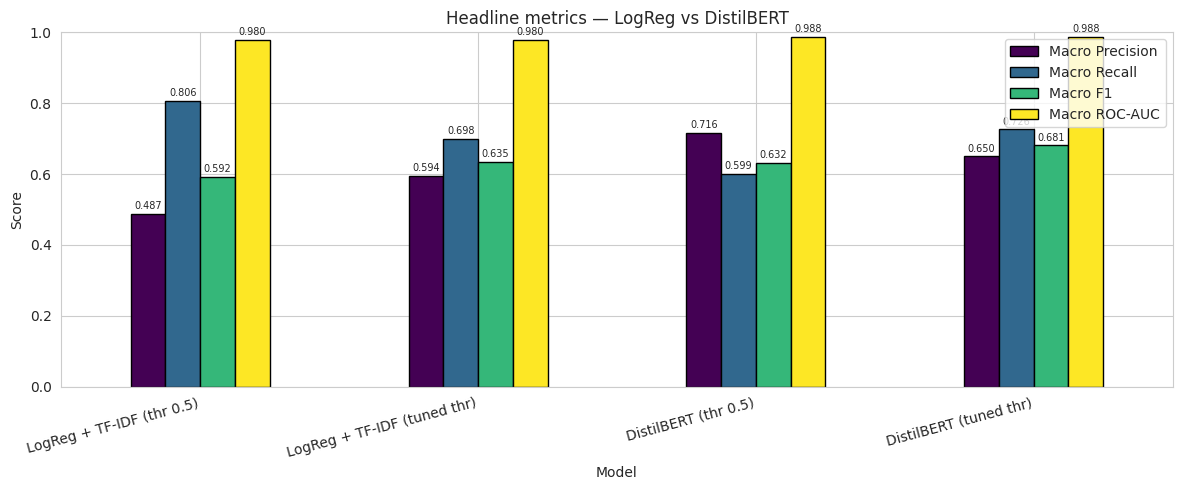

In [ ]:
# Bar chart of headline metrics
metrics_to_plot = ['Macro Precision', 'Macro Recall', 'Macro F1', 'Macro ROC-AUC']
ax = results[metrics_to_plot].plot(kind='bar', figsize=(12, 5),
                                    colormap='viridis', edgecolor='black')
ax.set_ylim(0, 1)
ax.set_title('Headline metrics — LogReg vs DistilBERT')
ax.set_ylabel('Score')
plt.xticks(rotation=15, ha='right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=7)
plt.tight_layout(); plt.show()

### 9.2 Per-label F1


               LogReg  DistilBERT
toxic           0.783       0.825
severe_toxic    0.489       0.524
obscene         0.820       0.838
threat          0.498       0.557
insult          0.736       0.769
identity_hate   0.484       0.572


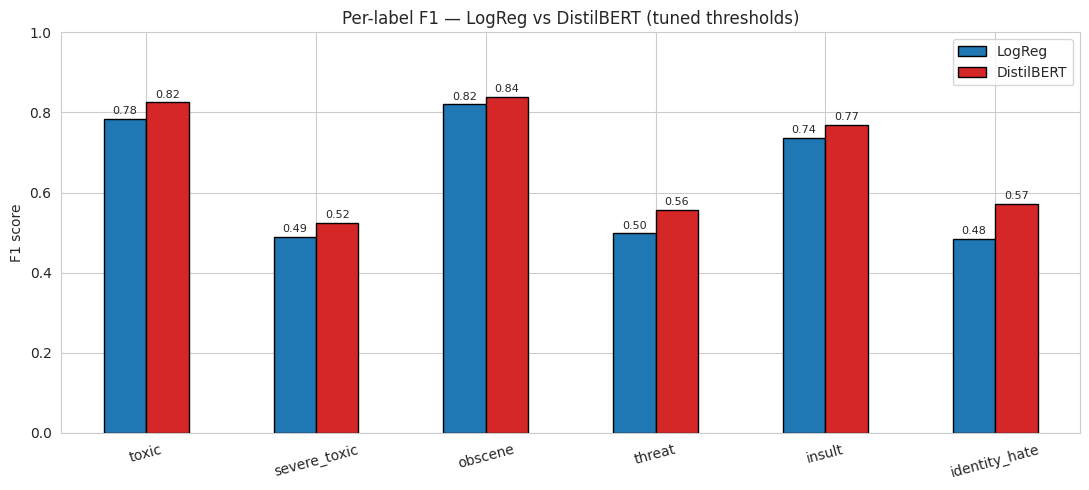

In [ ]:
def per_label_f1(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred,
                                                  average=None, zero_division=0)
    return p, r, f

_, _, f1_lr   = per_label_f1(y_val,      y_pred_lr_t)
_, _, f1_bert = per_label_f1(y_val_bert, y_pred_bert_t)

per_label = pd.DataFrame({'LogReg': f1_lr, 'DistilBERT': f1_bert}, index=LABEL_COLS).round(3)
print(per_label)

ax = per_label.plot(kind='bar', figsize=(11, 5),
                    color=['#1f77b4', '#d62728'], edgecolor='black')
ax.set_ylim(0, 1)
ax.set_ylabel('F1 score')
ax.set_title('Per-label F1 — LogReg vs DistilBERT (tuned thresholds)')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2, fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

### 9.3 Confusion matrices


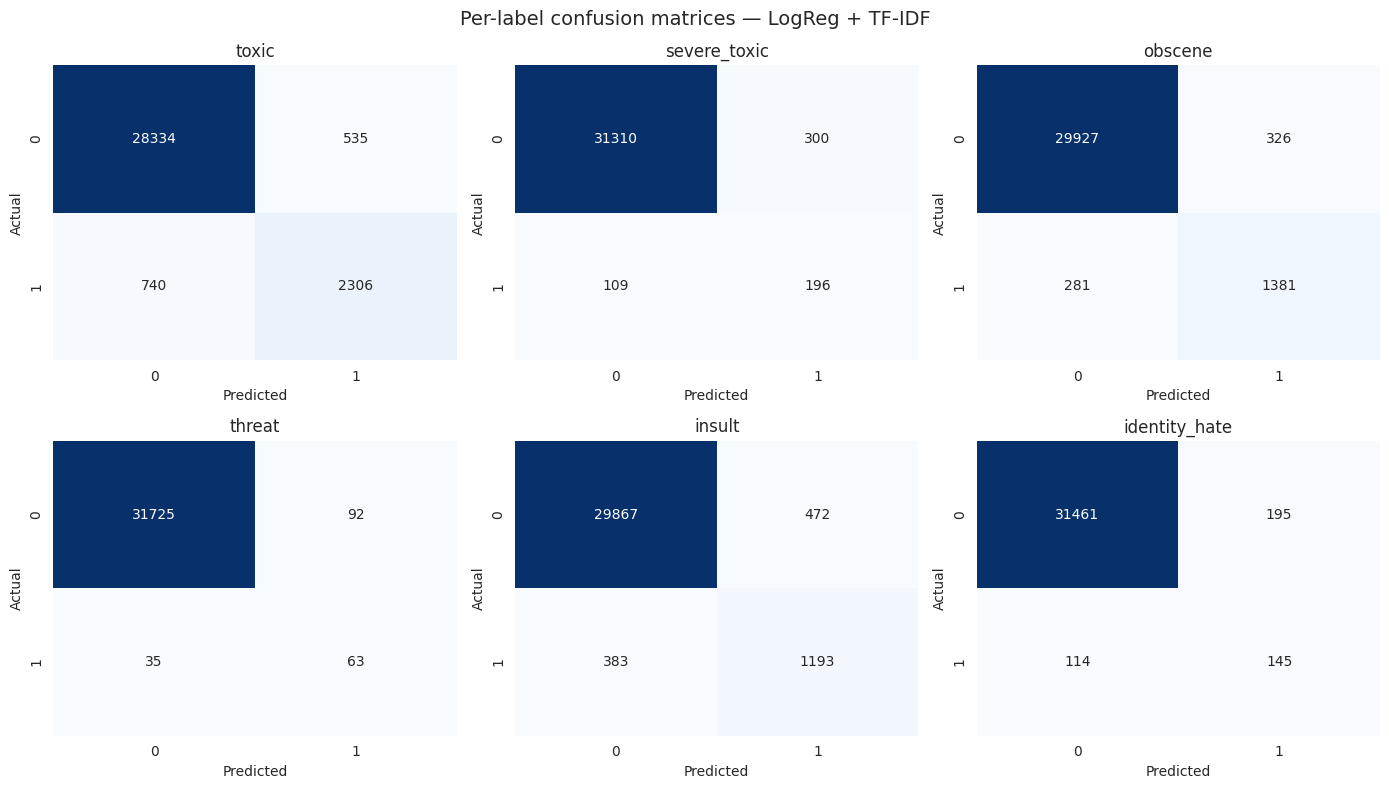

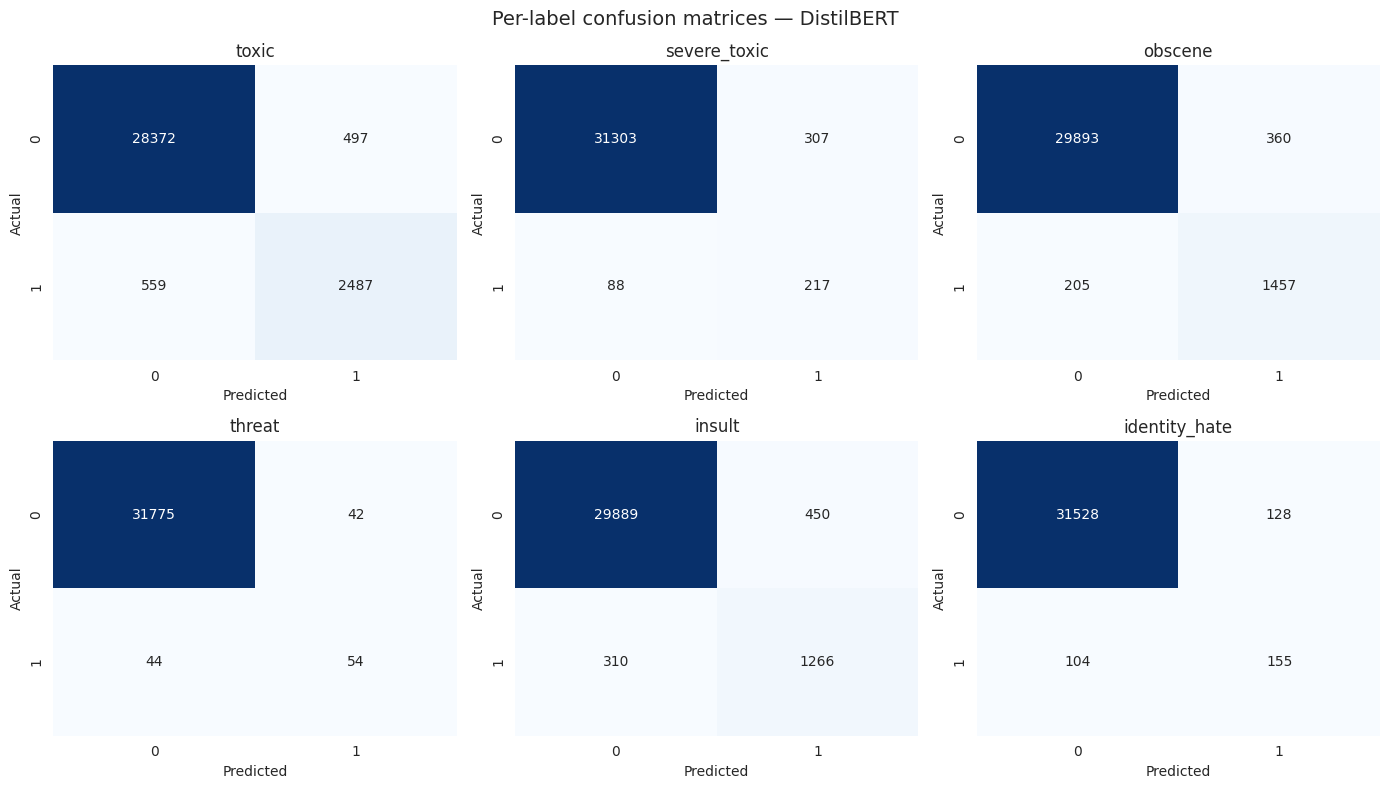

In [ ]:
def plot_cm_grid(y_true, y_pred, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, label, idx in zip(axes.flat, LABEL_COLS, range(len(LABEL_COLS))):
        cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(label)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

plot_cm_grid(y_val,      y_pred_lr_t,   'Per-label confusion matrices — LogReg + TF-IDF')
plot_cm_grid(y_val_bert, y_pred_bert_t, 'Per-label confusion matrices — DistilBERT')

### 9.4 ROC curves


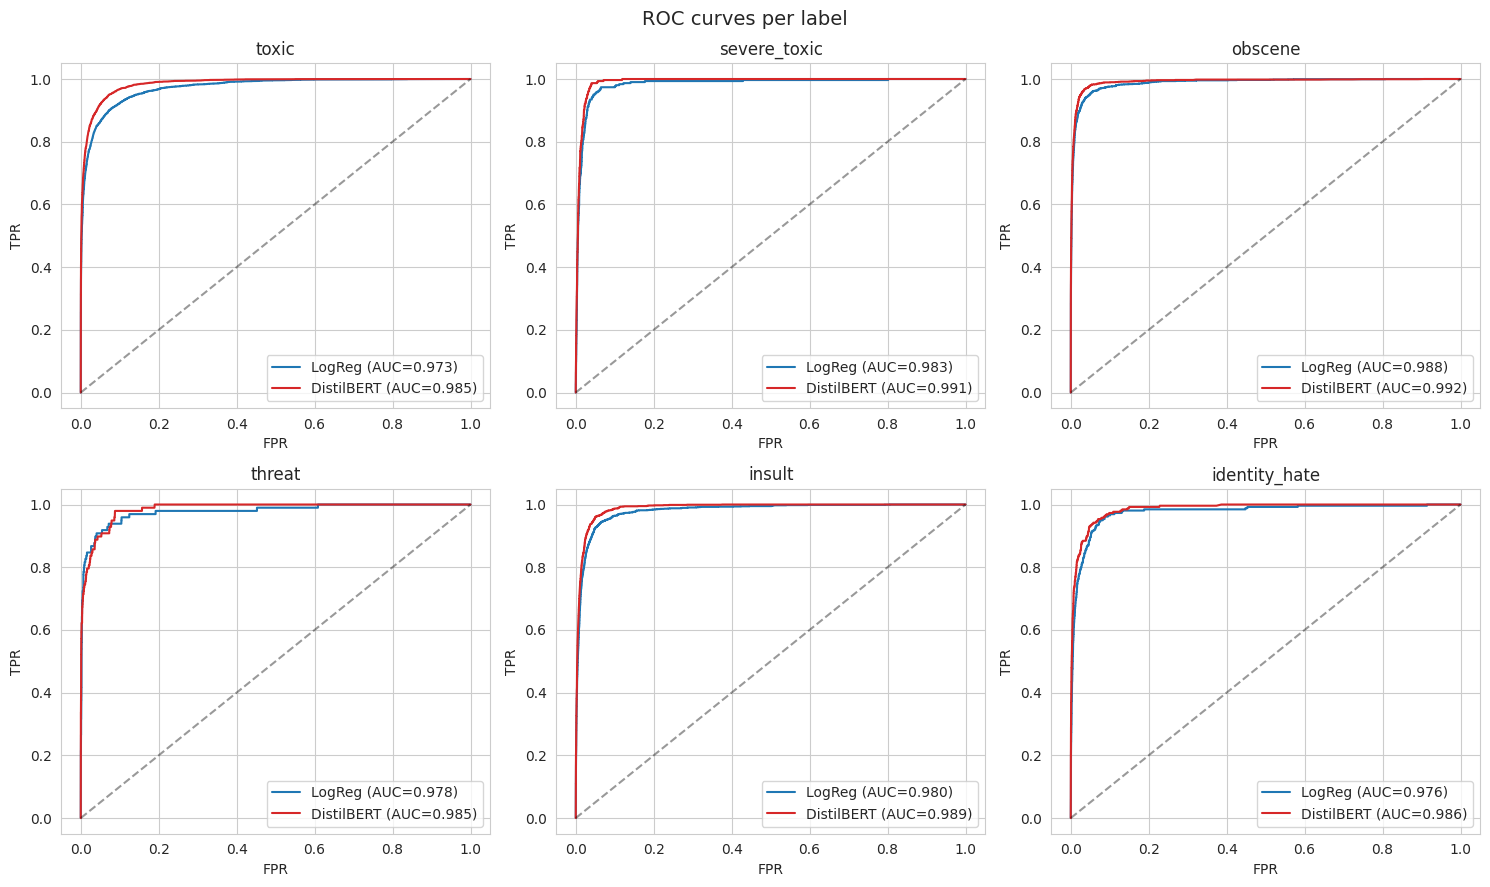

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, label, idx in zip(axes.flat, LABEL_COLS, range(len(LABEL_COLS))):
    fpr_lr,   tpr_lr,   _ = roc_curve(y_val[:, idx],      y_proba_lr[:, idx])
    fpr_bert, tpr_bert, _ = roc_curve(y_val_bert[:, idx], y_proba_bert[:, idx])
    auc_lr   = roc_auc_score(y_val[:, idx],      y_proba_lr[:, idx])
    auc_bert = roc_auc_score(y_val_bert[:, idx], y_proba_bert[:, idx])
    ax.plot(fpr_lr,   tpr_lr,   label=f'LogReg (AUC={auc_lr:.3f})',     color='#1f77b4')
    ax.plot(fpr_bert, tpr_bert, label=f'DistilBERT (AUC={auc_bert:.3f})', color='#d62728')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(label); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(loc='lower right')
plt.suptitle('ROC curves per label', fontsize=14)
plt.tight_layout(); plt.show()

### 9.5 Learning curve


In [ ]:
# ----- Learning curve for TF-IDF + Logistic Regression -----
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
ls_results = []

for frac in fractions:
    n = int(len(X_train_text) * frac)
    rng = np.random.RandomState(RANDOM_STATE)
    sub = rng.choice(len(X_train_text), size=n, replace=False)
    Xs, ys = X_train_text[sub], y_train[sub]

    tf_ = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2),
                          max_features=50000, min_df=3,
                          strip_accents='unicode',
                          token_pattern=r'\w{1,}')
    Xs_v = tf_.fit_transform(Xs)
    Xv_v = tf_.transform(X_val_text)
    clf = OneVsRestClassifier(
        LogisticRegression(C=4.0, solver='liblinear',
                           class_weight='balanced', max_iter=1000)
    )
    clf.fit(Xs_v, ys)
    yp = clf.predict(Xv_v); pp = clf.predict_proba(Xv_v)
    ls_results.append({
        'fraction'      : frac,
        'n_samples'     : n,
        'macro_f1'      : f1_score(y_val, yp, average='macro', zero_division=0),
        'micro_f1'      : f1_score(y_val, yp, average='micro', zero_division=0),
        'macro_roc_auc' : roc_auc_score(y_val, pp, average='macro'),
    })
    print(f'  frac={frac:>4.2f}  n={n:>6,}  macroF1={ls_results[-1]["macro_f1"]:.4f}  '
          f'AUC={ls_results[-1]["macro_roc_auc"]:.4f}')

ls_df = pd.DataFrame(ls_results)
ls_df


  frac=0.10  n=12,765  macroF1=0.5633  AUC=0.9640
  frac=0.25  n=31,914  macroF1=0.5862  AUC=0.9747
  frac=0.50  n=63,828  macroF1=0.5907  AUC=0.9777
  frac=0.75  n=95,742  macroF1=0.5932  AUC=0.9790
  frac=1.00  n=127,656  macroF1=0.5920  AUC=0.9796


,fraction,n_samples,macro_f1,micro_f1,macro_roc_auc
0,0.10,12765,0.563272,0.704381,0.963994
1,0.25,31914,0.586244,0.712746,0.974657
2,0.50,63828,0.590679,0.712627,0.977676
3,0.75,95742,0.593172,0.712618,0.978985
4,1.00,127656,0.592003,0.709906,0.979552


  saved -> report/figures/learning_curve_dataset_size.png
  saved -> report 2/figures/learning_curve_dataset_size.png


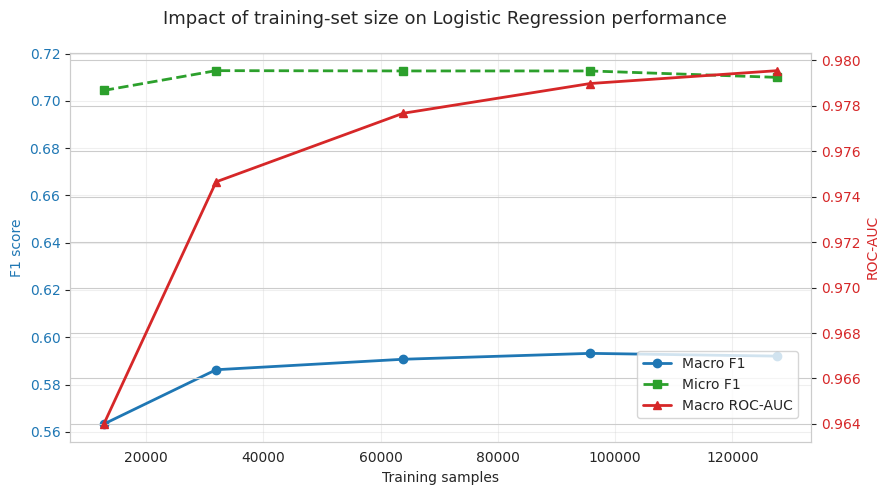

In [ ]:
# Plot the learning curve
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(ls_df['n_samples'], ls_df['macro_f1'], 'o-',
         color='#1f77b4', linewidth=2, label='Macro F1')
ax1.plot(ls_df['n_samples'], ls_df['micro_f1'], 's--',
         color='#2ca02c', linewidth=2, label='Micro F1')
ax1.set_xlabel('Training samples')
ax1.set_ylabel('F1 score', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2 = ax1.twinx()
ax2.plot(ls_df['n_samples'], ls_df['macro_roc_auc'], '^-',
         color='#d62728', linewidth=2, label='Macro ROC-AUC')
ax2.set_ylabel('ROC-AUC', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
fig.suptitle('Impact of training-set size on Logistic Regression performance',
             fontsize=13)
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
ax1.grid(alpha=0.3)
plt.tight_layout()
savefig('learning_curve_dataset_size')
plt.show()


### 9.6 Hyperparameter sweep


     C  macro_f1  micro_f1  macro_roc_auc
0  0.1    0.5070    0.6405         0.9807
1  0.5    0.5395    0.6708         0.9821
2  1.0    0.5578    0.6857         0.9819
3  2.0    0.5740    0.6969         0.9810
4  4.0    0.5920    0.7099         0.9796
5  8.0    0.6002    0.7143         0.9773
  saved -> report/figures/hyperparam_logreg_C.png
  saved -> report 2/figures/hyperparam_logreg_C.png


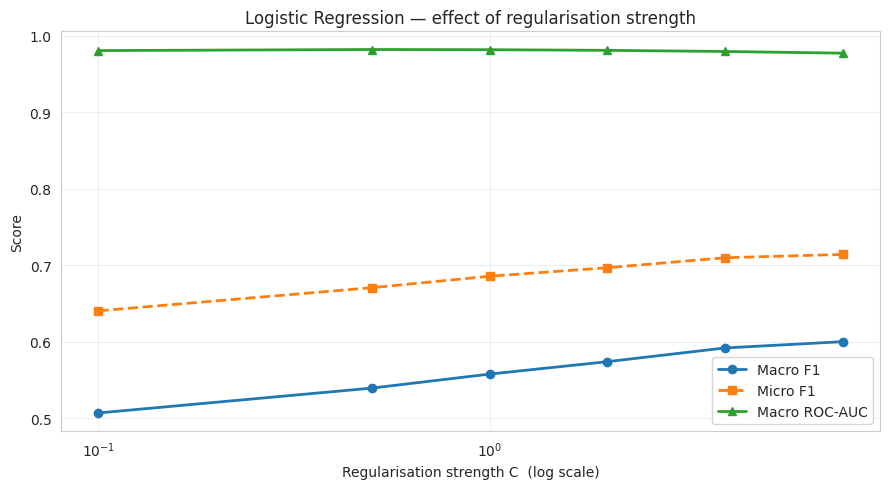

In [ ]:
# ----- 9.6.1  Effect of regularisation strength C on Logistic Regression -----
C_grid = [0.1, 0.5, 1.0, 2.0, 4.0, 8.0]
hp_rows = []

for C in C_grid:
    clf = OneVsRestClassifier(
        LogisticRegression(C=C, solver='liblinear',
                           class_weight='balanced', max_iter=1000)
    )
    clf.fit(X_train_tfidf, y_train)
    yp = clf.predict(X_val_tfidf); pp = clf.predict_proba(X_val_tfidf)
    hp_rows.append({
        'C'             : C,
        'macro_f1'      : f1_score(y_val, yp, average='macro', zero_division=0),
        'micro_f1'      : f1_score(y_val, yp, average='micro', zero_division=0),
        'macro_roc_auc' : roc_auc_score(y_val, pp, average='macro'),
    })

hp_df = pd.DataFrame(hp_rows)
print(hp_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hp_df['C'], hp_df['macro_f1'], 'o-',  label='Macro F1', linewidth=2)
ax.plot(hp_df['C'], hp_df['micro_f1'], 's--', label='Micro F1', linewidth=2)
ax.plot(hp_df['C'], hp_df['macro_roc_auc'], '^-', label='Macro ROC-AUC', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Regularisation strength C  (log scale)')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression — effect of regularisation strength')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
savefig('hyperparam_logreg_C')
plt.show()


  saved -> report/figures/hyperparam_threshold_macroF1.png
  saved -> report 2/figures/hyperparam_threshold_macroF1.png


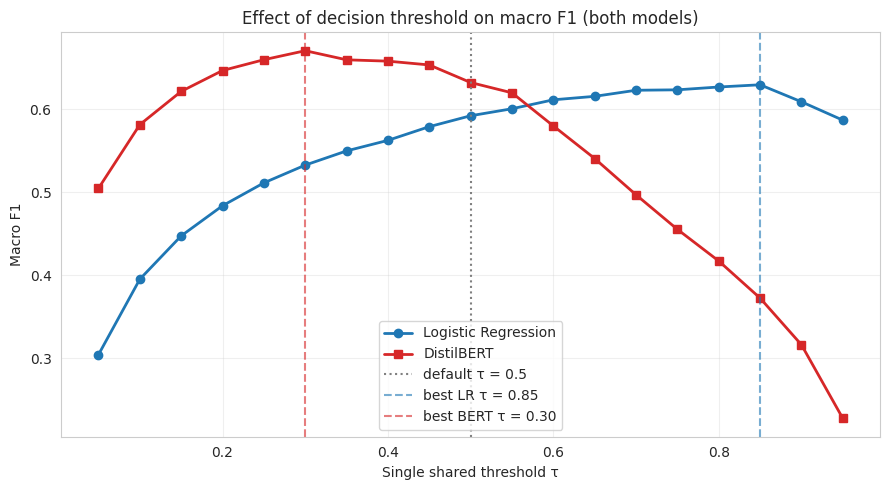

In [ ]:
# ----- 9.6.2  Macro-F1 vs decision threshold for both models -----
thr_grid = np.linspace(0.05, 0.95, 19)

def macro_f1_curve(y_true, y_proba):
    return [f1_score(y_true, (y_proba >= t).astype(int),
                     average='macro', zero_division=0) for t in thr_grid]

mf1_lr   = macro_f1_curve(y_val,      y_proba_lr)
mf1_bert = macro_f1_curve(y_val_bert, y_proba_bert)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr_grid, mf1_lr,   'o-', label='Logistic Regression', color='#1f77b4', linewidth=2)
ax.plot(thr_grid, mf1_bert, 's-', label='DistilBERT',          color='#d62728', linewidth=2)
ax.axvline(0.5, color='grey', linestyle=':', label='default τ = 0.5')
best_lr   = thr_grid[int(np.argmax(mf1_lr))]
best_bert = thr_grid[int(np.argmax(mf1_bert))]
ax.axvline(best_lr,   color='#1f77b4', linestyle='--', alpha=0.6,
           label=f'best LR τ = {best_lr:.2f}')
ax.axvline(best_bert, color='#d62728', linestyle='--', alpha=0.6,
           label=f'best BERT τ = {best_bert:.2f}')
ax.set_xlabel('Single shared threshold τ')
ax.set_ylabel('Macro F1')
ax.set_title('Effect of decision threshold on macro F1 (both models)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
savefig('hyperparam_threshold_macroF1')
plt.show()


  saved -> report/figures/pr_curves_per_label.png
  saved -> report 2/figures/pr_curves_per_label.png


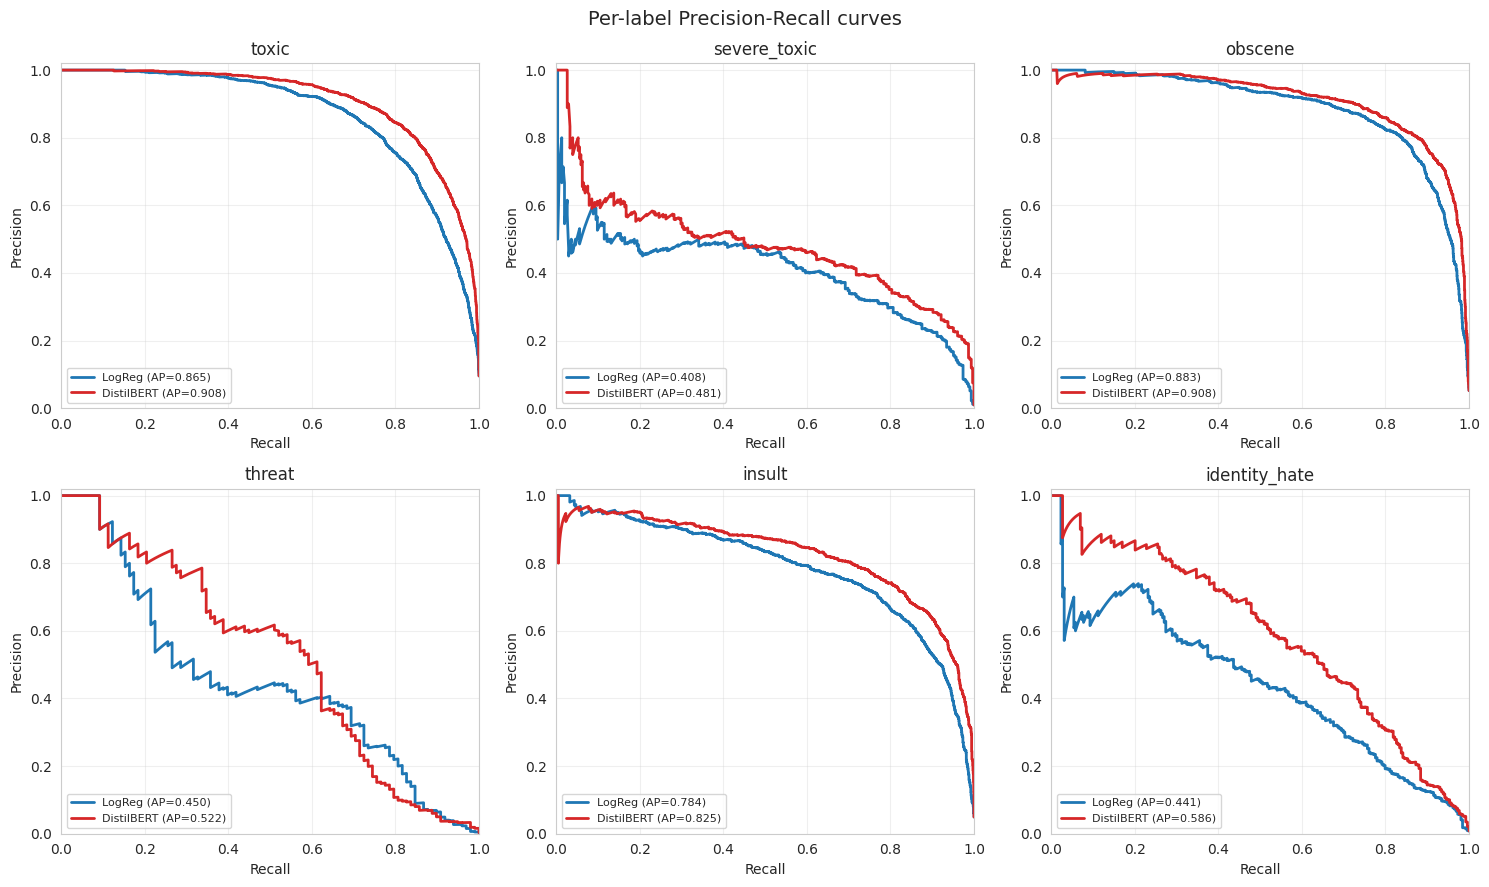

In [ ]:
# ----- 9.6.3  Per-label Precision-Recall curves -----
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, label, idx in zip(axes.flat, LABEL_COLS, range(len(LABEL_COLS))):
    p_lr, r_lr, _   = precision_recall_curve(y_val[:, idx],      y_proba_lr[:, idx])
    p_bt, r_bt, _   = precision_recall_curve(y_val_bert[:, idx], y_proba_bert[:, idx])
    ap_lr = average_precision_score(y_val[:, idx],      y_proba_lr[:, idx])
    ap_bt = average_precision_score(y_val_bert[:, idx], y_proba_bert[:, idx])
    ax.plot(r_lr, p_lr, label=f'LogReg (AP={ap_lr:.3f})',     color='#1f77b4', linewidth=2)
    ax.plot(r_bt, p_bt, label=f'DistilBERT (AP={ap_bt:.3f})', color='#d62728', linewidth=2)
    ax.set_title(label); ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Per-label Precision-Recall curves', fontsize=14)
plt.tight_layout()
savefig('pr_curves_per_label')
plt.show()


### 9.7 Error analysis


In [ ]:
def error_analysis(label, y_true_col, y_proba_col, comments, k=3):
    """Return top false-positive and false-negative examples for one label."""
    df = pd.DataFrame({
        'comment': comments,
        'y'      : y_true_col,
        'p'      : y_proba_col,
    })
    fn = df[df['y'] == 1].sort_values('p', ascending=True).head(k)
    fp = df[df['y'] == 0].sort_values('p', ascending=False).head(k)
    return fn, fp

# Use the validation comment text aligned with the validation indices we used
val_comments = train_df['comment_text'].values[idx_val]

print('='*78)
print('  TOP CONFIDENT MISTAKES — Logistic Regression')
print('='*78)
for j, label in enumerate(LABEL_COLS):
    fn, fp = error_analysis(label, y_val[:, j], y_proba_lr[:, j], val_comments, k=2)
    print(f'\n--- {label} ---')
    print('  False negatives (model said clean, was actually toxic):')
    for _, row in fn.iterrows():
        print(f'    p={row["p"]:.3f}  ::  {str(row["comment"])[:140]}')
    print('  False positives (model flagged, was actually clean):')
    for _, row in fp.iterrows():
        print(f'    p={row["p"]:.3f}  ::  {str(row["comment"])[:140]}')


  TOP CONFIDENT MISTAKES — Logistic Regression

--- toxic ---
  False negatives (model said clean, was actually toxic):
    p=0.002  ::  your argument becomes even weaker if you re now going to rely upon your hopes and wishes that the subject has  moved on it is clear that the
    p=0.004  ::  how long did it take you to make that snippy comment mister d f cf  ce d
  False positives (model flagged, was actually clean):
    p=1.000  ::    lecture someone else  sarah  you are talking down  you re talking down a teacher talks to a disobedient child  get off the pedestal and do
    p=1.000  ::    i get none as i am a gob shit e 

--- severe_toxic ---
  False negatives (model said clean, was actually toxic):
    p=0.001  ::   where does it say that featured articles have different requirements then other articles  jeepday the whole point in to get citations for a
    p=0.003  ::  bush us evil  he s selfish and very short tempered  he shouldn t even be in control of a pet shop let alone a na

In [ ]:
print('='*78)
print('  TOP CONFIDENT MISTAKES — DistilBERT')
print('='*78)
# val_comments_bert lines up with y_val_bert / y_proba_bert (same val indices)
val_comments_bert = train_df['comment_text'].values[idx_val]
for j, label in enumerate(LABEL_COLS):
    fn, fp = error_analysis(label, y_val_bert[:, j], y_proba_bert[:, j],
                             val_comments_bert, k=2)
    print(f'\n--- {label} ---')
    print('  False negatives:')
    for _, row in fn.iterrows():
        print(f'    p={row["p"]:.3f}  ::  {str(row["comment"])[:140]}')
    print('  False positives:')
    for _, row in fp.iterrows():
        print(f'    p={row["p"]:.3f}  ::  {str(row["comment"])[:140]}')


  TOP CONFIDENT MISTAKES — DistilBERT

--- toxic ---
  False negatives:
    p=0.001  ::  restored  ought to be this article ought to be restored to the original version of years  the one we had before the p rverts and kikes took 
    p=0.001  ::  the only help i need is the removal of deletionist administrators such as yourself  as you can see from my contributions  i add quite a bit 
  False positives:
    p=0.991  ::  bollocks to this you ignorant  cunt  
    p=0.987  ::  w hate ver your all a bunch of  cunt s 

--- severe_toxic ---
  False negatives:
    p=0.001  ::  bush us evil  he s selfish and very short tempered  he shouldn t even be in control of a pet shop let alone a nation and he claims to be the
    p=0.003  ::   where does it say that featured articles have different requirements then other articles  jeepday the whole point in to get citations for a
  False positives:
    p=0.704  ::   bitch you are a fuck  ing hore  you  suck  dick you big ass hole  you are  gay  you fag

               LogReg error rate  DistilBERT error rate
toxic                     0.0399                 0.0331
severe_toxic              0.0128                 0.0124
obscene                   0.0190                 0.0177
threat                    0.0040                 0.0027
insult                    0.0268                 0.0238
identity_hate             0.0097                 0.0073
  saved -> report/figures/error_rate_per_label.png
  saved -> report 2/figures/error_rate_per_label.png


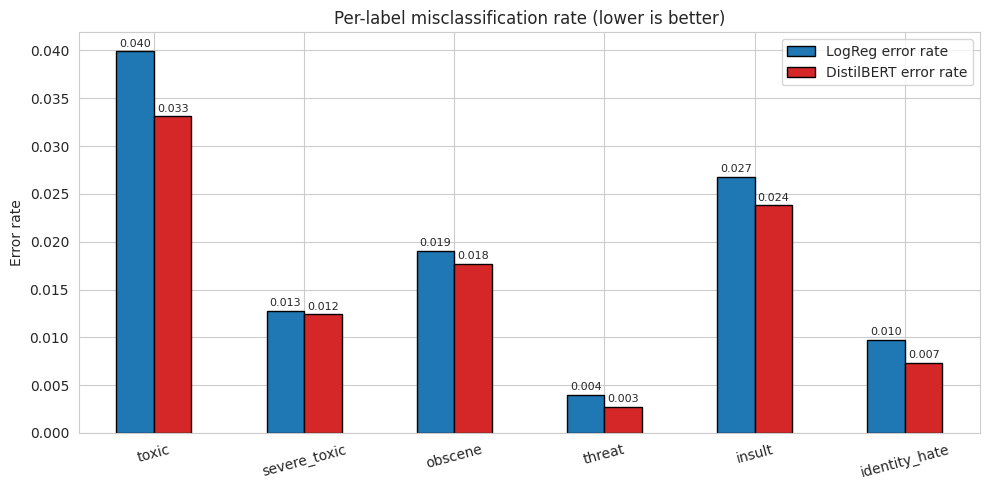

In [ ]:
# Misclassification rate per label (LR vs DistilBERT, tuned thresholds)
err_lr   = (y_pred_lr_t   != y_val).mean(axis=0)
err_bert = (y_pred_bert_t != y_val_bert).mean(axis=0)

err_df = pd.DataFrame({'LogReg error rate': err_lr,
                       'DistilBERT error rate': err_bert},
                      index=LABEL_COLS).round(4)
print(err_df)

ax = err_df.plot(kind='bar', figsize=(10, 5),
                 color=['#1f77b4', '#d62728'], edgecolor='black')
ax.set_ylabel('Error rate')
ax.set_title('Per-label misclassification rate (lower is better)')
plt.xticks(rotation=15)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
savefig('error_rate_per_label')
plt.show()


### 9.8 Save figures


  saved -> report/figures/label_distribution.png
  saved -> report 2/figures/label_distribution.png


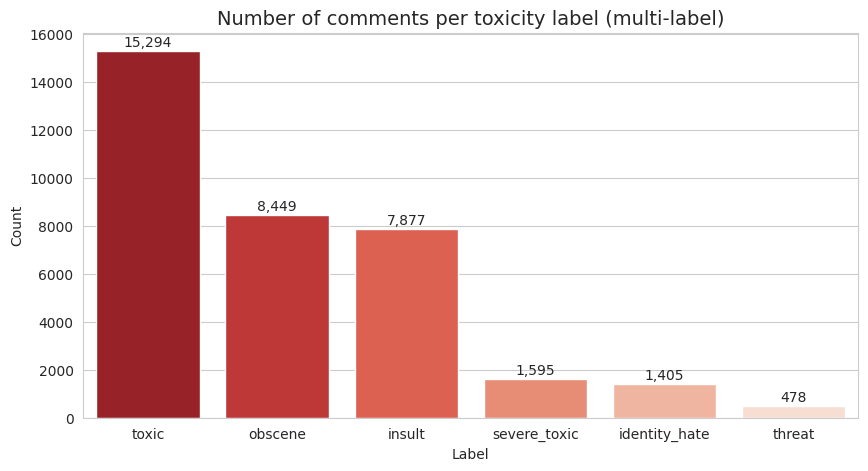

  saved -> report/figures/headline_metrics_comparison.png
  saved -> report 2/figures/headline_metrics_comparison.png


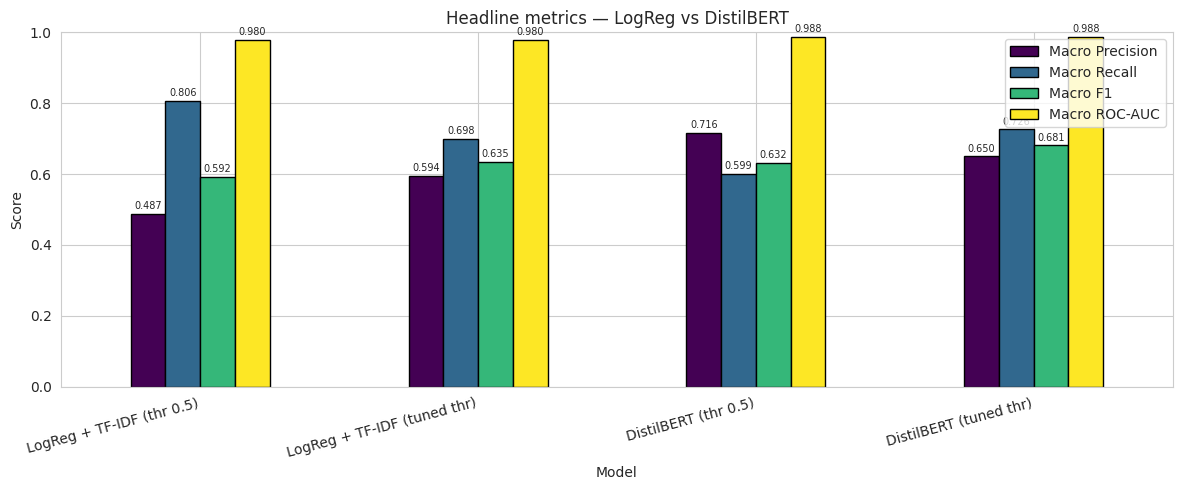

  saved -> report/figures/per_label_f1.png
  saved -> report 2/figures/per_label_f1.png


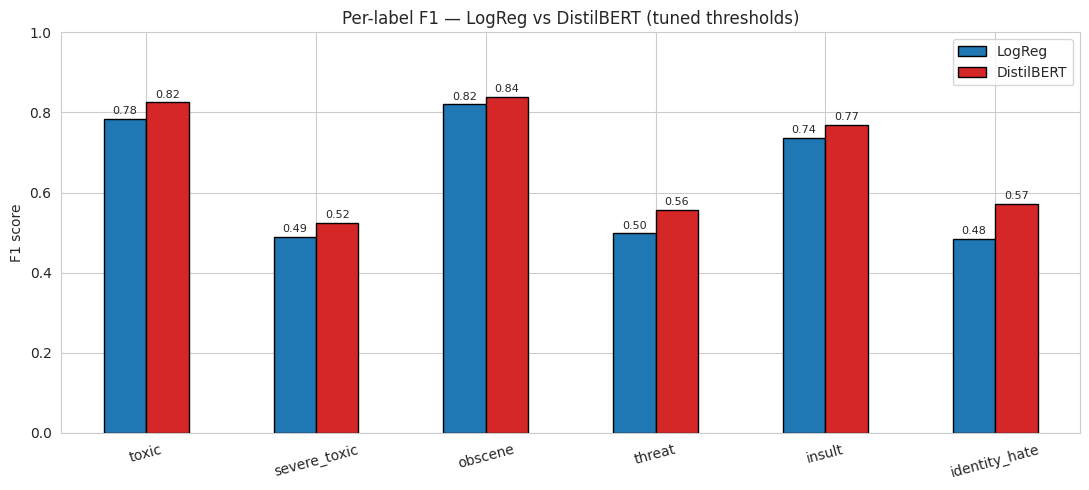

  saved -> report/figures/cm_logreg.png
  saved -> report 2/figures/cm_logreg.png


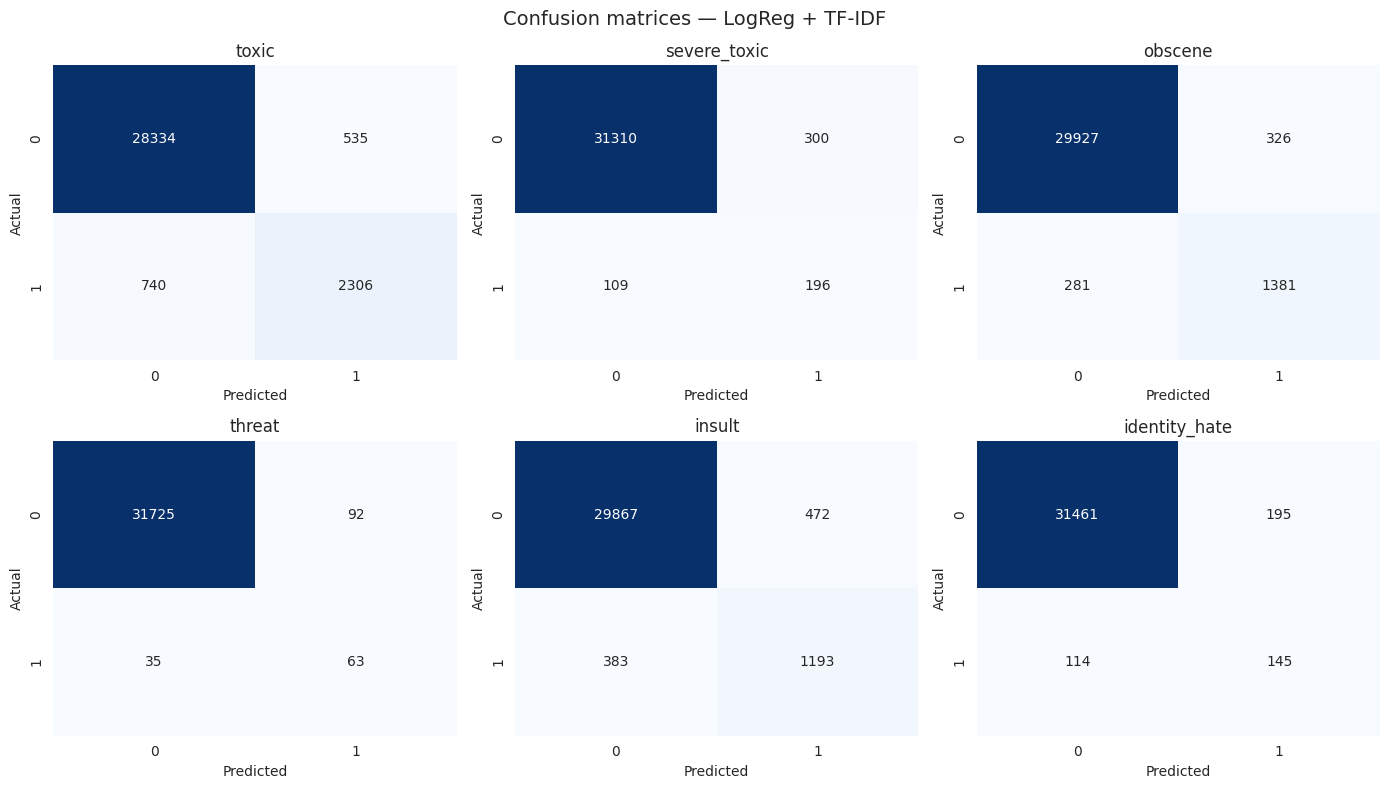

  saved -> report/figures/cm_distilbert.png
  saved -> report 2/figures/cm_distilbert.png


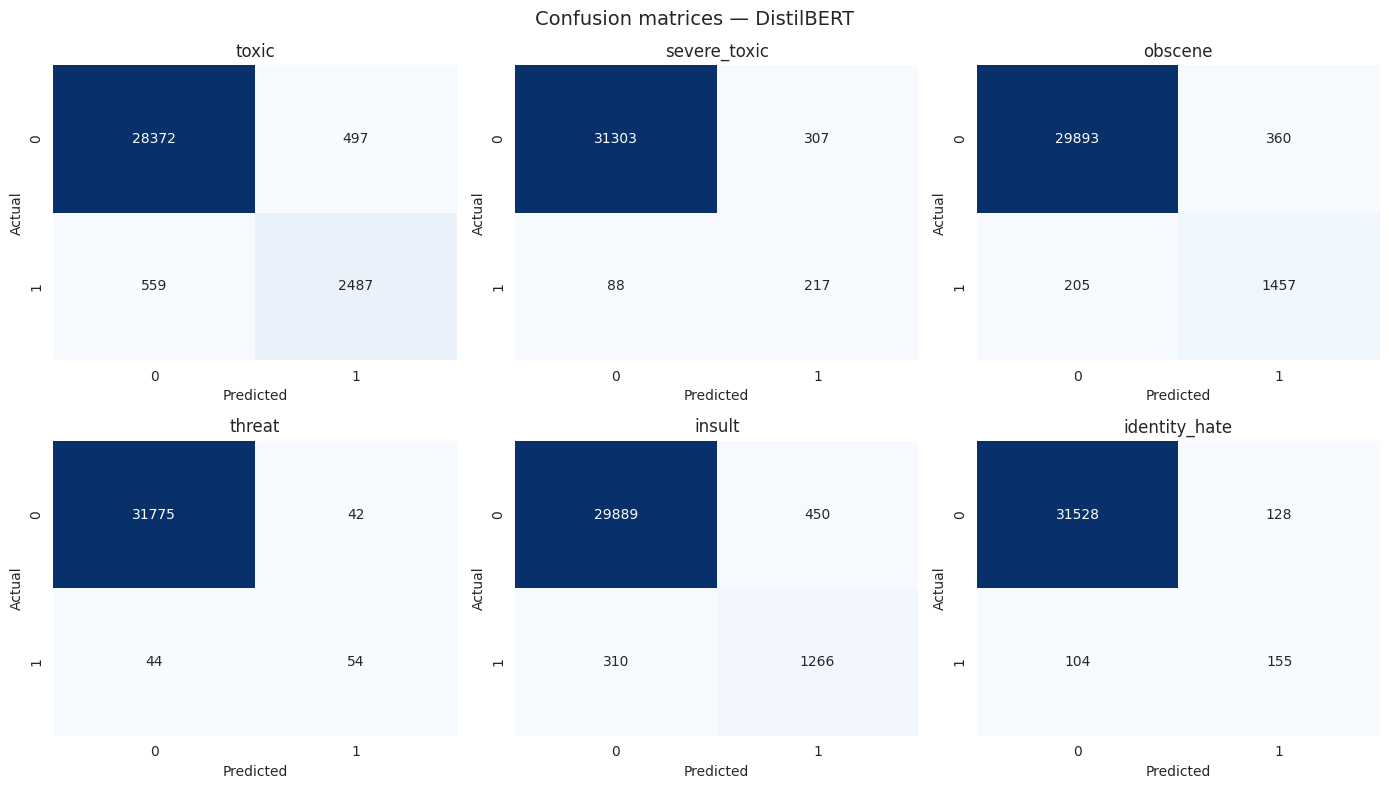

  saved -> report/figures/roc_curves_per_label.png
  saved -> report 2/figures/roc_curves_per_label.png


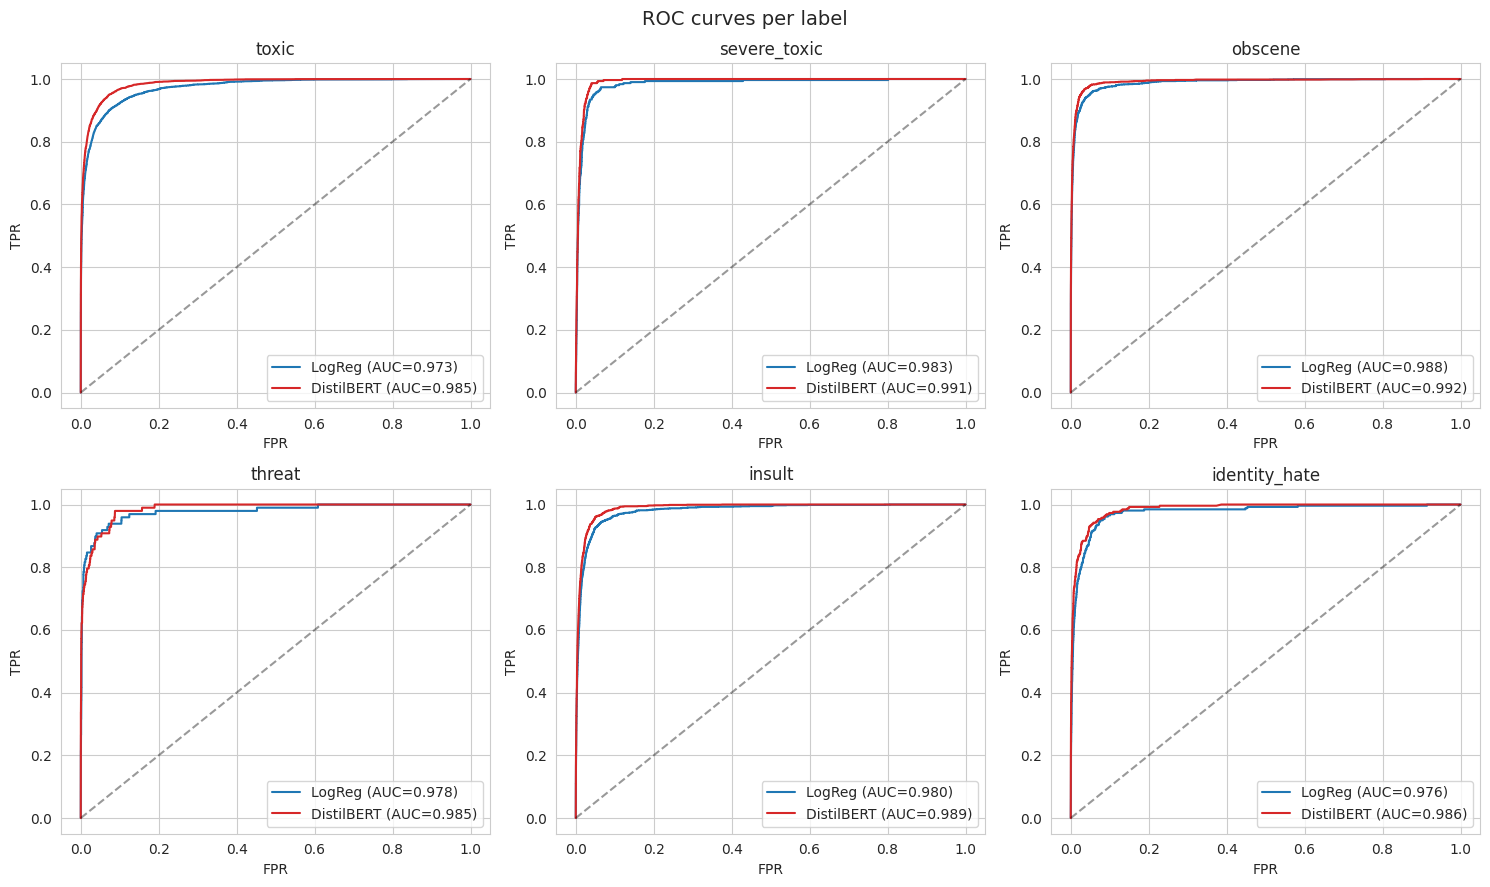


All headline figures saved to report/figures/.


In [ ]:
# 1) Label distribution
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')
plt.title('Number of comments per toxicity label (multi-label)', fontsize=14)
plt.ylabel('Count'); plt.xlabel('Label')
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
savefig('label_distribution'); plt.show()

# 2) Headline metrics bar chart
ax = results[['Macro Precision', 'Macro Recall', 'Macro F1', 'Macro ROC-AUC']].plot(
    kind='bar', figsize=(12, 5), colormap='viridis', edgecolor='black')
ax.set_ylim(0, 1)
ax.set_title('Headline metrics — LogReg vs DistilBERT')
ax.set_ylabel('Score')
plt.xticks(rotation=15, ha='right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=7)
plt.tight_layout()
savefig('headline_metrics_comparison'); plt.show()

# 3) Per-label F1
ax = per_label.plot(kind='bar', figsize=(11, 5),
                    color=['#1f77b4', '#d62728'], edgecolor='black')
ax.set_ylim(0, 1); ax.set_ylabel('F1 score')
ax.set_title('Per-label F1 — LogReg vs DistilBERT (tuned thresholds)')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2, fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
savefig('per_label_f1'); plt.show()

# 4) Confusion matrices (best model)
def cm_grid(y_true, y_pred, title, fname):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, label, idx in zip(axes.flat, LABEL_COLS, range(len(LABEL_COLS))):
        cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(label); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(title, fontsize=14); plt.tight_layout()
    savefig(fname); plt.show()

cm_grid(y_val,      y_pred_lr_t,   'Confusion matrices — LogReg + TF-IDF',
        'cm_logreg')
cm_grid(y_val_bert, y_pred_bert_t, 'Confusion matrices — DistilBERT',
        'cm_distilbert')

# 5) ROC curves
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, label, idx in zip(axes.flat, LABEL_COLS, range(len(LABEL_COLS))):
    fpr_lr,   tpr_lr,   _ = roc_curve(y_val[:, idx],      y_proba_lr[:, idx])
    fpr_bert, tpr_bert, _ = roc_curve(y_val_bert[:, idx], y_proba_bert[:, idx])
    auc_lr   = roc_auc_score(y_val[:, idx],      y_proba_lr[:, idx])
    auc_bert = roc_auc_score(y_val_bert[:, idx], y_proba_bert[:, idx])
    ax.plot(fpr_lr,   tpr_lr,   label=f'LogReg (AUC={auc_lr:.3f})',     color='#1f77b4')
    ax.plot(fpr_bert, tpr_bert, label=f'DistilBERT (AUC={auc_bert:.3f})', color='#d62728')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(label); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right')
plt.suptitle('ROC curves per label', fontsize=14)
plt.tight_layout()
savefig('roc_curves_per_label'); plt.show()

print('\nAll headline figures saved to report/figures/.')


## 10. Qualitative Inference


In [ ]:
def predict_lr(comments, thr=thr_lr):
    cleaned = [' '.join(tok.lemma_ for tok in nlp(remove_stopwords(basic_clean(c))))
               for c in comments]
    p = lr.predict_proba(tfidf.transform(cleaned))
    return [(c, dict(zip(LABEL_COLS, np.round(pi, 3))),
             [l for l, s, t in zip(LABEL_COLS, pi, thr) if s >= t] or ['CLEAN'])
            for c, pi in zip(comments, p)]

def predict_bert(comments, thr=thr_bert):
    model.eval()
    enc = tokenizer(list(comments), truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt')
    with torch.no_grad():
        out = model(input_ids=enc['input_ids'].to(DEVICE),
                    attention_mask=enc['attention_mask'].to(DEVICE))
    p = torch.sigmoid(out.logits).cpu().numpy()
    return [(c, dict(zip(LABEL_COLS, np.round(pi, 3))),
             [l for l, s, t in zip(LABEL_COLS, pi, thr) if s >= t] or ['CLEAN'])
            for c, pi in zip(comments, p)]

examples = [
    'You are an amazing person and I love your work!',
    'I will hunt you down and make you pay, idiot.',
    'shut up moron nobody cares about your stupid opinion',
    'This article is poorly written but the topic is interesting.',
]

print('--- Logistic Regression ---')
for c, scores, flags in predict_lr(examples):
    print(f'\n{c}\n  flagged: {flags}\n  scores : {scores}')

print('\n--- DistilBERT ---')
for c, scores, flags in predict_bert(examples):
    print(f'\n{c}\n  flagged: {flags}\n  scores : {scores}')

--- Logistic Regression ---

You are an amazing person and I love your work!
  flagged: ['CLEAN']
  scores : {'toxic': np.float64(0.031), 'severe_toxic': np.float64(0.011), 'obscene': np.float64(0.007), 'threat': np.float64(0.001), 'insult': np.float64(0.006), 'identity_hate': np.float64(0.003)}

I will hunt you down and make you pay, idiot.
  flagged: ['toxic', 'obscene', 'insult']
  scores : {'toxic': np.float64(1.0), 'severe_toxic': np.float64(0.013), 'obscene': np.float64(0.796), 'threat': np.float64(0.17), 'insult': np.float64(0.997), 'identity_hate': np.float64(0.01)}

shut up moron nobody cares about your stupid opinion
  flagged: ['toxic', 'obscene', 'insult']
  scores : {'toxic': np.float64(1.0), 'severe_toxic': np.float64(0.446), 'obscene': np.float64(0.996), 'threat': np.float64(0.004), 'insult': np.float64(1.0), 'identity_hate': np.float64(0.248)}

This article is poorly written but the topic is interesting.
  flagged: ['CLEAN']
  scores : {'toxic': np.float64(0.013), 'seve

## 11. Discussion
# 
### In our experiments, the fine-tuned DistilBERT model outperformed the traditional Logistic Regression model with TF-IDF features across most evaluation metrics, including macro precision, macro recall, and macro F1 score. DistilBERT demonstrated a much stronger ability to detect nuanced and minority toxic content categories, resulting in higher overall performance, especially in more challenging multi-label settings.
#
### Based on these results, we chose the DistilBERT model as our preferred approach for toxic language detection due to its superior accuracy and robustness, despite its higher computational cost compared to the logistic regression baseline.

## 12. Conclusion
### In this study, we explored and rigorously compared two prominent approaches for multi-label toxic language detection: traditional machine learning using TF-IDF representations combined with Logistic Regression, and deep learning leveraging a fine-tuned DistilBERT transformer model. Our experiments revealed that, while both models achieve strong overall accuracy, the fine-tuned DistilBERT clearly outperforms the traditional approach across several key metrics, particularly macro precision, macro recall, and macro F1, and demonstrates superior ability to detect minority and hard-to-classify toxicity categories.
# 
### We also observed that careful threshold tuning and preprocessing steps can yield meaningful performance improvements—especially in traditional models—narrowing the gap with BERT-based methods in some areas. However, deep learning models, with their contextual understanding and capacity for nuanced representations, are better equipped for the complexity and variety inherent in real-world online toxicity detection tasks.
# 
### The trade-off for these performance benefits is higher computational cost and inference time for transformer models compared to classical methods, a consideration when deploying at scale. Ultimately, our findings affirm the value of modern NLP advances in addressing societal problems such as toxic content, while highlighting the continued relevance of classic methods for resource-constrained settings. Future work could investigate hybrid strategies and explore even more sophisticated models to further advance automated toxic language detection.
# </div>